# MBE Generation-Stage Hallucination Experiment — Analysis Notebook

**Model:** llama-3.3-70b-versatile (Groq free tier)  
**Structured to match thesis §4 Results (Sections 4.1 – 4.6)**

All production-quality figures are generated at the end via `thesis_figures.py`.  
Exploratory outputs are saved to `results/analysis/`.


In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import chi2 as chi2_dist, norm as norm_dist

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RESULTS_ZS  = 'results/zero_shot'
RESULTS_FS  = 'results/few_shot'
FM_PATH     = 'results/failure_modes_baseline.csv'
FIG_DIR     = 'results/analysis'
os.makedirs(FIG_DIR, exist_ok=True)

COND_NAMES = {
    0: 'Baseline',
    1: 'Grounding',
    2: 'Rule Extraction',
    3: 'Chain of Logic',
    4: 'Neg. Elimination',
    5: 'Answer Verification',
    6: 'Self-Consistency',
    7: 'Rule Ext. + CoL',
}
COND_FILES = {
    0: 'condition_0_baseline.csv',
    1: 'condition_1_grounding.csv',
    2: 'condition_2_rule_extraction.csv',
    3: 'condition_3_chain_of_logic.csv',
    4: 'condition_4_negative_elimination.csv',
    5: 'condition_5_answer_verification.csv',
    6: 'condition_6_self_consistency.csv',
    7: 'condition_7_rule_col.csv',
}
SUBJECTS = ['CONST. LAW', 'CONTRACTS', 'CRIM. LAW', 'EVIDENCE', 'REAL PROP.', 'TORTS']
COLORS = sns.color_palette('tab10', 8)


def wilson_ci(n_correct, n_total, alpha=0.05):
    """Wilson score confidence interval (no external dependencies)."""
    if n_total == 0:
        return 0., 0.
    z = norm_dist.ppf(1 - alpha / 2)
    p = n_correct / n_total
    denom = 1 + z**2 / n_total
    center = (p + z**2 / (2 * n_total)) / denom
    margin = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denom
    return max(0., center - margin), min(1., center + margin)


def mcnemar_test(correct_a, correct_b):
    """McNemar's test with continuity correction. Inputs are boolean Series."""
    b = int(( correct_a & ~correct_b).sum())   # A right, B wrong
    c = int((~correct_a &  correct_b).sum())   # A wrong, B right
    if b + c == 0:
        return np.nan, np.nan, np.nan
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - chi2_dist.cdf(stat, df=1)
    phi  = np.sqrt(stat / (b + c))             # effect size
    return stat, p, phi

## 0. Setup and Data Loading

In [2]:
def load_mode(results_dir):
    """Load all condition CSVs from a results directory into a single DataFrame."""
    dfs = []
    for cid, fname in COND_FILES.items():
        path = os.path.join(results_dir, fname)
        if not os.path.exists(path):
            print(f'  Missing: {path}')
            continue
        df = pd.read_csv(path)
        df['condition_id'] = cid
        df['condition_name'] = COND_NAMES[cid]
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    combined['is_correct'] = combined['is_correct'].astype(bool)
    return combined

print('Loading zero-shot results...')
zs = load_mode(RESULTS_ZS)
print(f'  {len(zs):,} rows, {zs["condition_id"].nunique()} conditions')

print('Loading few-shot results...')
fs = load_mode(RESULTS_FS)
print(f'  {len(fs):,} rows, {fs["condition_id"].nunique()} conditions')

# Only keep questions present in all conditions (inner join on idx)
def filter_complete(df):
    counts = df.groupby('idx')['condition_id'].nunique()
    complete_idx = counts[counts == df['condition_id'].nunique()].index
    return df[df['idx'].isin(complete_idx)].copy()

zs_complete = filter_complete(zs)
fs_complete = filter_complete(fs)
print(f'\nComplete questions — zero-shot: {zs_complete["idx"].nunique()}, few-shot: {fs_complete["idx"].nunique()}')

# Load failure modes (classified on zero-shot baseline errors)
fm = pd.read_csv(FM_PATH) if os.path.exists(FM_PATH) else None
if fm is not None:
    print(f'Failure modes: {len(fm)} rows, FM distribution:')
    print(fm['failure_mode'].value_counts().to_dict())

Loading zero-shot results...


  9,560 rows, 8 conditions
Loading few-shot results...


  9,544 rows, 8 conditions

Complete questions — zero-shot: 1195, few-shot: 1193
Failure modes: 431 rows, FM distribution:
{'FM2': 308, 'FM1': 123}


## §4.1 Baseline Performance and Failure Mode Characterisation

Primary accuracy table (§4.1.1) and FM taxonomy (§4.1.2–4.1.4).  
Panel (a) = Zero-Shot; Panel (b) = Few-Shot (discussed in §4.5.1).  
Wilson 95% CIs and McNemar's test vs. baseline (C0).

In [3]:
def accuracy_table(df, label=''):
    """Accuracy + 95% Wilson CI + McNemar vs baseline."""
    pivot = df.pivot_table(index='idx', columns='condition_id',
                           values='is_correct', aggfunc='first')
    n = len(pivot)
    baseline_correct = pivot[0].astype(bool)
    
    rows = []
    for cid in sorted(COND_NAMES):
        if cid not in pivot.columns:
            continue
        col = pivot[cid].astype(bool)
        n_correct = int(col.sum())
        acc = n_correct / n
        lo, hi = wilson_ci(n_correct, n)
        delta = acc - (int(baseline_correct.sum()) / n)

        if cid == 0:
            p_val, phi_val, sig = np.nan, np.nan, ''
        else:
            _, p_val, phi_val = mcnemar_test(baseline_correct, col)
            if not np.isnan(p_val):
                sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
            else:
                sig = ''

        rows.append({
            'Cond': cid,
            'Name': COND_NAMES[cid],
            'N': n,
            'Accuracy': acc,
            'CI_lo': lo,
            'CI_hi': hi,
            'CI 95%': f'[{lo:.3f}, {hi:.3f}]',
            'Δ vs Baseline': delta,
            'McNemar p': p_val,
            'φ (effect)': phi_val,
            'Sig*': sig,
        })

    return pd.DataFrame(rows)


tbl_zs = accuracy_table(zs_complete, 'Zero-shot')
tbl_fs = accuracy_table(fs_complete, 'Few-shot')

display_cols = ['Cond', 'Name', 'N', 'Accuracy', 'CI 95%', 'Δ vs Baseline', 'McNemar p', 'φ (effect)', 'Sig*']
fmt = {'Accuracy': '{:.3f}', 'Δ vs Baseline': '{:+.3f}',
       'McNemar p': '{:.4f}', 'φ (effect)': '{:.3f}'}
print('ZERO-SHOT:')
display(tbl_zs[display_cols].style.format(fmt, na_rep='—'))
print('\nFEW-SHOT:')
display(tbl_fs[display_cols].style.format(fmt, na_rep='—'))

ZERO-SHOT:


,Cond,Name,N,Accuracy,CI 95%,Δ vs Baseline,McNemar p,φ (effect),Sig*
0,0,Baseline,1195,0.639,"[0.612, 0.666]",+0.000,—,—,
1,1,Grounding,1195,0.617,"[0.589, 0.644]",-0.023,0.0181,0.215,*
2,2,Rule Extraction,1195,0.633,"[0.605, 0.660]",-0.007,0.4094,0.097,
3,3,Chain of Logic,1195,0.632,"[0.604, 0.659]",-0.008,0.4350,0.076,
4,4,Neg. Elimination,1195,0.608,"[0.580, 0.636]",-0.031,0.0008,0.313,***
5,5,Answer Verification,1195,0.628,"[0.600, 0.655]",-0.012,0.0714,0.250,
6,6,Self-Consistency,1195,0.629,"[0.602, 0.656]",-0.010,0.1272,0.212,
7,7,Rule Ext. + CoL,1195,0.630,"[0.602, 0.657]",-0.009,0.3337,0.093,



FEW-SHOT:


,Cond,Name,N,Accuracy,CI 95%,Δ vs Baseline,McNemar p,φ (effect),Sig*
0,0,Baseline,1193,0.604,"[0.575, 0.631]",+0.000,—,—,
1,1,Grounding,1193,0.592,"[0.564, 0.619]",-0.012,0.3010,0.082,
2,2,Rule Extraction,1193,0.684,"[0.657, 0.710]",+0.080,0.0000,0.534,***
3,3,Chain of Logic,1193,0.801,"[0.777, 0.822]",+0.197,0.0000,0.674,***
4,4,Neg. Elimination,1193,0.786,"[0.762, 0.809]",+0.183,0.0000,0.646,***
5,5,Answer Verification,1193,0.799,"[0.775, 0.821]",+0.195,0.0000,0.672,***
6,6,Self-Consistency,1193,0.798,"[0.774, 0.820]",+0.194,0.0000,0.672,***
7,7,Rule Ext. + CoL,1193,0.785,"[0.761, 0.808]",+0.182,0.0000,0.615,***


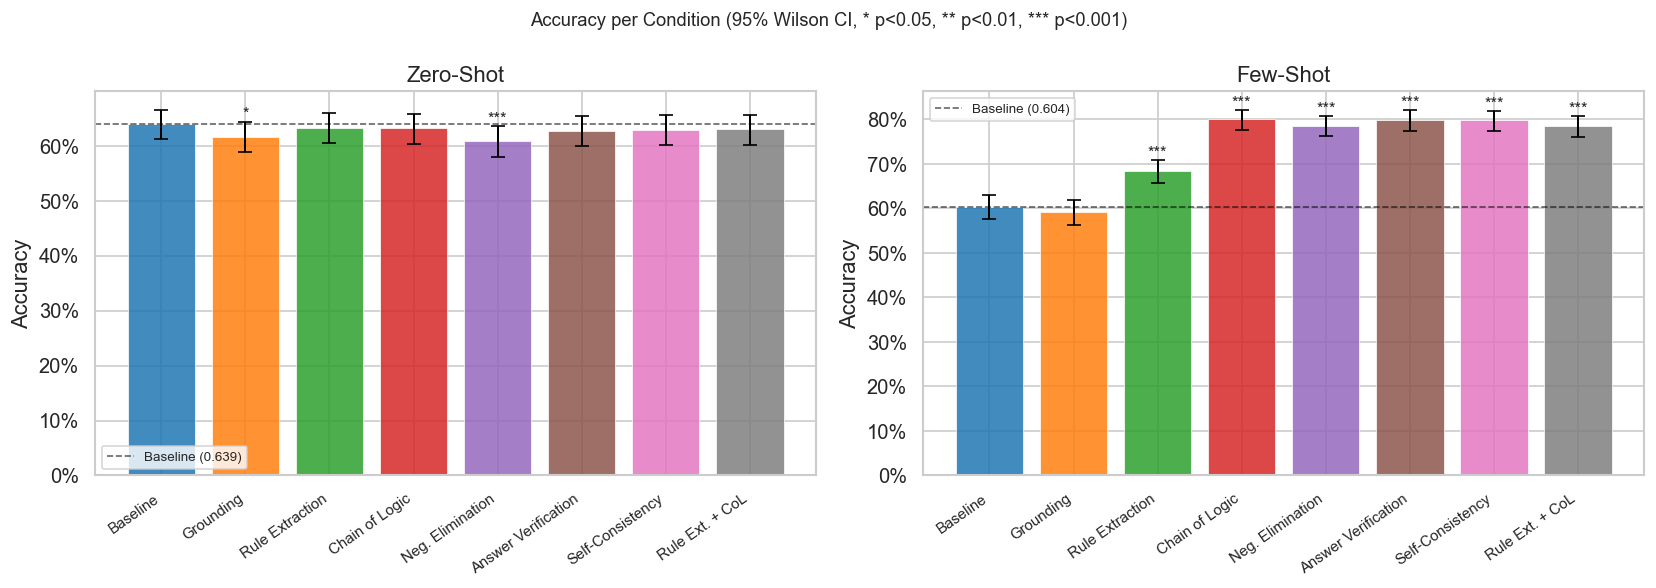

In [4]:
# --- Plot: Accuracy per condition with CIs, zero-shot vs few-shot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, tbl, title in zip(axes, [tbl_zs, tbl_fs], ['Zero-Shot', 'Few-Shot']):
    x = range(len(tbl))
    ax.bar(x, tbl['Accuracy'], color=[COLORS[i] for i in tbl['Cond']],
           alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.errorbar(x, tbl['Accuracy'],
                yerr=[tbl['Accuracy'] - tbl['CI_lo'], tbl['CI_hi'] - tbl['Accuracy']],
                fmt='none', color='black', capsize=4, linewidth=1.2)
    baseline_acc = tbl.loc[tbl['Cond'] == 0, 'Accuracy'].values[0]
    ax.axhline(baseline_acc, color='black', linestyle='--', linewidth=1, alpha=0.6,
               label=f'Baseline ({baseline_acc:.3f})')
    ax.set_xticks(x)
    ax.set_xticklabels(tbl['Name'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)
    for xi, (_, row) in zip(x, tbl.iterrows()):
        if row['Sig*']:
            ax.text(xi, row['CI_hi'] + 0.005, row['Sig*'], ha='center', fontsize=10)

plt.suptitle('Accuracy per Condition (95% Wilson CI, * p<0.05, ** p<0.01, *** p<0.001)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'accuracy_per_condition.png'), bbox_inches='tight')
plt.show()

### §4.1.4 Confidence × Failure Mode
Mann-Whitney test: FM1 vs. FM2 confidence. Are parametric-override errors more overconfident than reasoning failures?

Correct    — mean confidence: 0.938  (n=764)
FM1 errors — mean confidence: 0.883  (n=123)
FM2 errors — mean confidence: 0.893  (n=308)

Mann-Whitney FM1 vs FM2 confidence: U=17502, p=0.2178


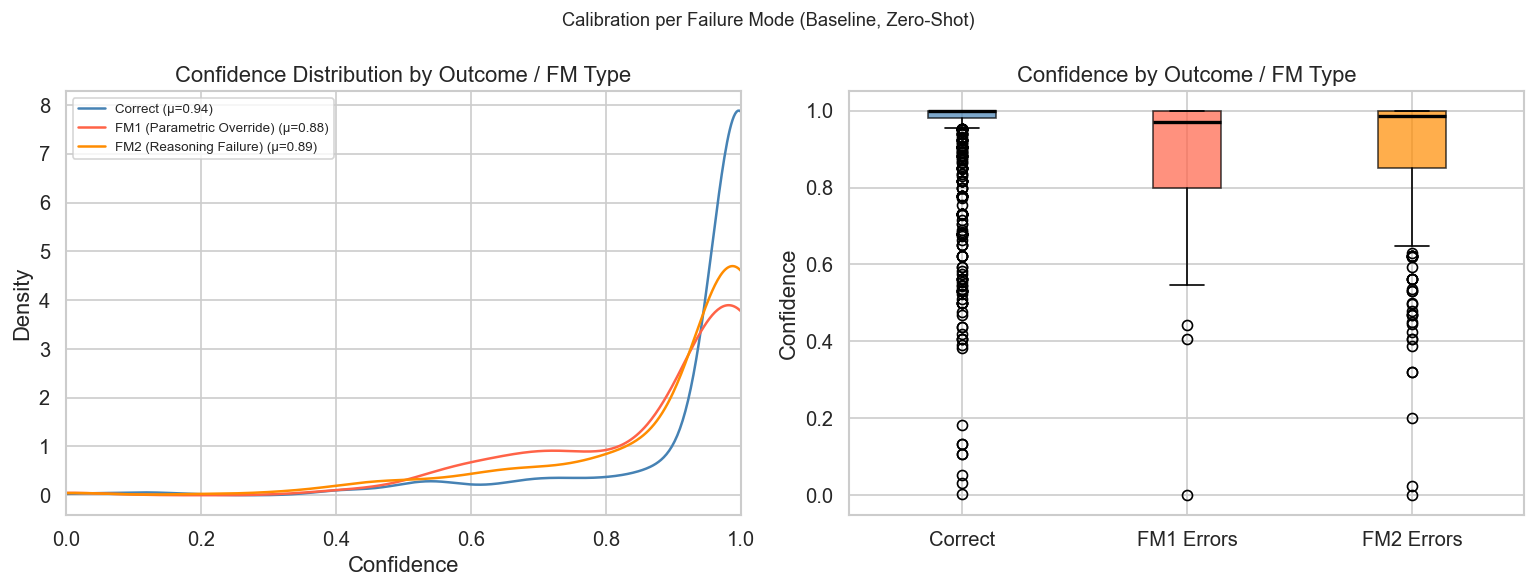

In [12]:
if fm is None:
    print('No failure modes CSV — skipping. Run: python classify_failures.py')
else:
    baseline_df = zs_complete[zs_complete['condition_id'] == 0].copy()
    baseline_df = baseline_df.merge(fm[['idx', 'failure_mode']], on='idx', how='left')

    correct    = baseline_df[baseline_df['is_correct'] == True]['confidence'].dropna()
    fm1_errors = baseline_df[(baseline_df['is_correct'] == False) &
                              (baseline_df['failure_mode'] == 'FM1')]['confidence'].dropna()
    fm2_errors = baseline_df[(baseline_df['is_correct'] == False) &
                              (baseline_df['failure_mode'] == 'FM2')]['confidence'].dropna()

    print(f'Correct    — mean confidence: {correct.mean():.3f}  (n={len(correct)})')
    print(f'FM1 errors — mean confidence: {fm1_errors.mean():.3f}  (n={len(fm1_errors)})')
    print(f'FM2 errors — mean confidence: {fm2_errors.mean():.3f}  (n={len(fm2_errors)})')

    if len(fm1_errors) > 0 and len(fm2_errors) > 0:
        u, p = stats.mannwhitneyu(fm1_errors, fm2_errors, alternative='two-sided')
        print(f'\nMann-Whitney FM1 vs FM2 confidence: U={u:.0f}, p={p:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    for data, lbl, color in [(correct, 'Correct', 'steelblue'),
                              (fm1_errors, 'FM1 (Parametric Override)', 'tomato'),
                              (fm2_errors, 'FM2 (Reasoning Failure)', 'darkorange')]:
        if len(data) > 1:
            data.plot.kde(ax=ax, label=f'{lbl} (μ={data.mean():.2f})', color=color)
    ax.set_xlabel('Confidence')
    ax.set_title('Confidence Distribution by Outcome / FM Type')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

    ax = axes[1]
    data_box = [correct, fm1_errors, fm2_errors]
    labels_box = ['Correct', 'FM1 Errors', 'FM2 Errors']
    bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato', 'darkorange']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Confidence')
    ax.set_title('Confidence by Outcome / FM Type')

    plt.suptitle('Calibration per Failure Mode (Baseline, Zero-Shot)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'calibration_per_fm.png'), bbox_inches='tight')
    plt.show()

### §4.1.2–4.1.3 Failure Mode Distribution (Overall and Per Subject)
Overall FM1/FM2 split and chi-squared test for subject-independence.

=== A12: Failure Mode × Subject (Zero-Shot Baseline) ===

   Subject  N (all Qs)  N errors  Error rate  FM1 n  FM2 n  FM1 %
CONST. LAW          95        12       12.6%      1     11   8.3%
 CONTRACTS         113        50       44.2%     15     35  30.0%
 CRIM. LAW          89        38       42.7%      9     29  23.7%
  EVIDENCE          93        37       39.8%     13     24  35.1%
REAL PROP.          92        44       47.8%     18     26  40.9%
     TORTS         112        45       40.2%     10     35  22.2%
   UNKNOWN         601       205       34.1%     57    148  27.8%

Chi-squared (FM × Subject, named only): χ²(5) = 7.71, p = 0.1730
  → Not significant: cannot reject subject-independence of FM split.

Pairwise Fisher exact (most extreme pairs):
  REAL PROP. (41%) vs CONST. LAW (8%): p=0.0428
  REAL PROP. (41%) vs TORTS (22%): p=0.0702
  EVIDENCE (35%) vs CONST. LAW (8%): p=0.1391

Unknown subject (n=205 errors): FM1=57 (27.8%), FM2=148 (72.2%)
Named subjects (n=226 errors): 

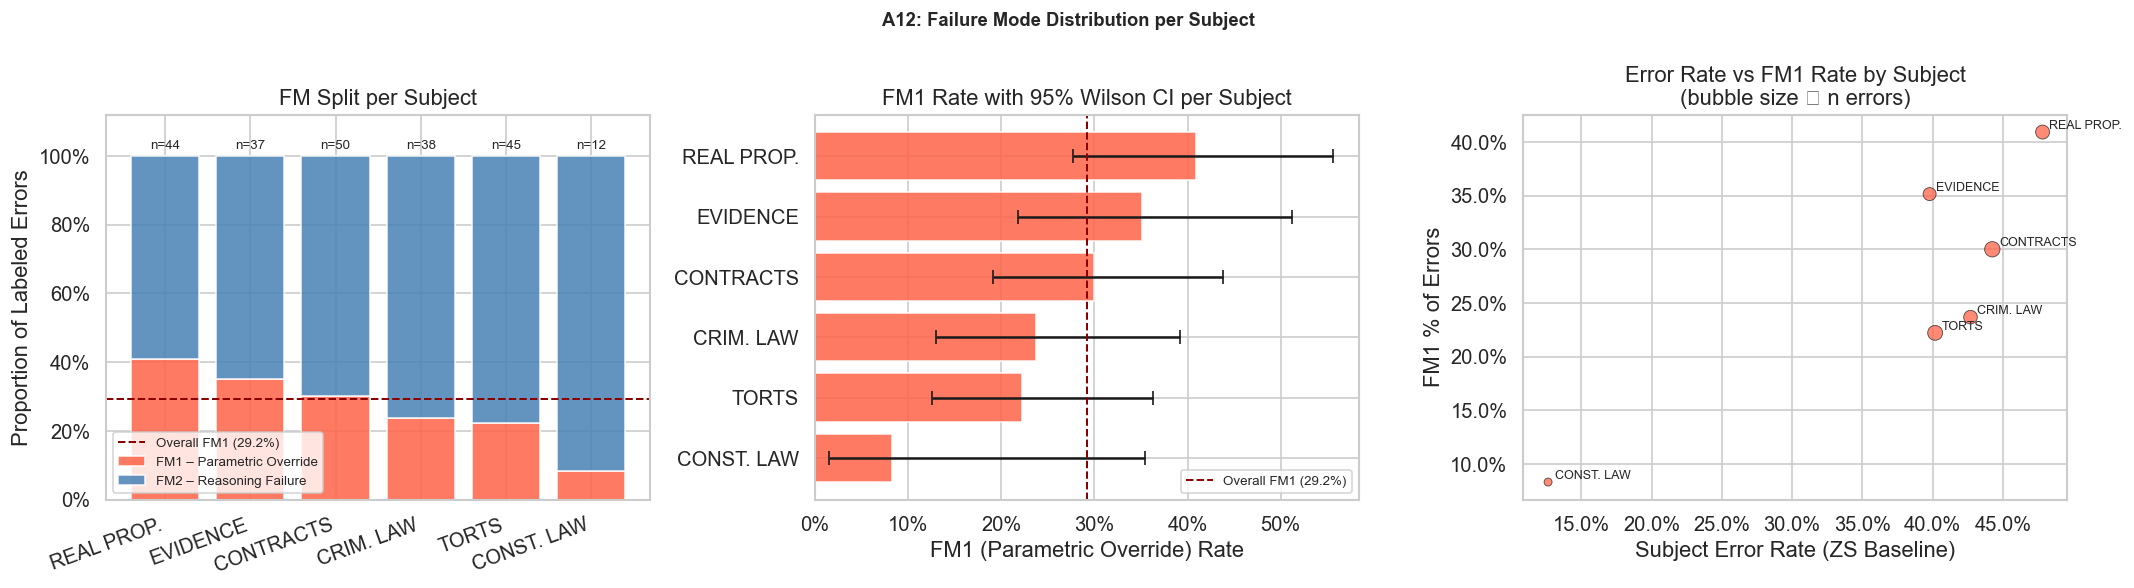

Saved: results/analysis/fm_per_subject.png


In [21]:
if fm is None:
    print('No failure modes CSV — skipping. Run: python classify_failures.py')
else:
    from scipy import stats as _stats
    from scipy.stats import fisher_exact, chi2_contingency

    # ------------------------------------------------------------------ #
    #  A12 – Per-Subject Failure Mode Distribution                        #
    # ------------------------------------------------------------------ #

    baseline_zs = zs_complete[zs_complete['condition_id'] == 0][['idx', 'subject', 'is_correct']].copy()
    baseline_zs = baseline_zs.merge(fm[['idx', 'failure_mode']], on='idx', how='left')

    # All rows including unknown subject
    wrong_all = baseline_zs[~baseline_zs['is_correct']].copy()
    wrong_all['subj_label'] = wrong_all['subject'].fillna('UNKNOWN')

    # Named-subject rows only
    wrong_named = wrong_all[wrong_all['subject'].isin(SUBJECTS)].copy()

    # ---- 1. Summary table -------------------------------------------- #
    rows = []
    for subj in SUBJECTS + ['UNKNOWN']:
        pool_all  = baseline_zs[baseline_zs['subject'].isna()] if subj == 'UNKNOWN' \
                    else baseline_zs[baseline_zs['subject'] == subj]
        sub = wrong_all[wrong_all['subj_label'] == subj] if subj == 'UNKNOWN' \
              else wrong_named[wrong_named['subject'] == subj]
        n_total   = len(pool_all)
        n_err     = len(sub)
        n_fm1     = (sub['failure_mode'] == 'FM1').sum()
        n_fm2     = (sub['failure_mode'] == 'FM2').sum()
        n_labeled = n_fm1 + n_fm2
        p_fm1     = n_fm1 / n_labeled if n_labeled else np.nan
        # Wilson 95% CI for FM1 proportion (inline, no statsmodels needed)
        if n_labeled > 0:
            z = 1.96
            p_hat = n_fm1 / n_labeled
            denom = 1 + z**2 / n_labeled
            center = (p_hat + z**2 / (2 * n_labeled)) / denom
            margin = z * np.sqrt(p_hat*(1-p_hat)/n_labeled + z**2/(4*n_labeled**2)) / denom
            lo, hi = center - margin, center + margin
        else:
            lo, hi = np.nan, np.nan
        rows.append({
            'Subject':       subj,
            'N (all Qs)':    n_total,
            'N errors':      n_err,
            'Error rate':    n_err / n_total if n_total else np.nan,
            'FM1 n':         int(n_fm1),
            'FM2 n':         int(n_fm2),
            'FM1 %':         p_fm1,
            'FM1 CI lo':     lo,
            'FM1 CI hi':     hi,
        })
    fm_subj_df = pd.DataFrame(rows)

    print('=== A12: Failure Mode × Subject (Zero-Shot Baseline) ===\n')
    print(fm_subj_df[['Subject','N (all Qs)','N errors','Error rate','FM1 n','FM2 n','FM1 %']]\
          .to_string(index=False, float_format='{:.1%}'.format))

    # ---- 2. Chi-square across named subjects -------------------------- #
    ct = pd.crosstab(wrong_named['subject'], wrong_named['failure_mode'])
    chi2_val, p_chi, dof, _ = chi2_contingency(ct)
    print(f'\nChi-squared (FM × Subject, named only): χ²({dof}) = {chi2_val:.2f}, p = {p_chi:.4f}')
    if p_chi < 0.05:
        print('  → Significant: FM split differs across subjects.')
    else:
        print('  → Not significant: cannot reject subject-independence of FM split.')

    # ---- 3. Pairwise Fisher exact: extremes --------------------------- #
    print('\nPairwise Fisher exact (most extreme pairs):')
    pairs = [
        ('REAL PROP.', 'CONST. LAW'),
        ('REAL PROP.', 'TORTS'),
        ('EVIDENCE',   'CONST. LAW'),
    ]
    for s1, s2 in pairs:
        r1 = ct.loc[s1] if s1 in ct.index else None
        r2 = ct.loc[s2] if s2 in ct.index else None
        if r1 is not None and r2 is not None:
            table = np.array([[r1.get('FM1',0), r1.get('FM2',0)],
                              [r2.get('FM1',0), r2.get('FM2',0)]])
            _, p_f = fisher_exact(table)
            n1, n2 = r1.sum(), r2.sum()
            fm1_1 = r1.get('FM1',0)/n1
            fm1_2 = r2.get('FM1',0)/n2
            print(f'  {s1} ({fm1_1:.0%}) vs {s2} ({fm1_2:.0%}): p={p_f:.4f}')

    # ---- 4. Unknown-subject breakdown --------------------------------- #
    unk = wrong_all[wrong_all['subj_label'] == 'UNKNOWN']
    n_unk = len(unk)
    fm1_unk = (unk['failure_mode'] == 'FM1').sum()
    fm2_unk = (unk['failure_mode'] == 'FM2').sum()
    print(f'\nUnknown subject (n={n_unk} errors): FM1={fm1_unk} ({fm1_unk/n_unk:.1%}), FM2={fm2_unk} ({fm2_unk/n_unk:.1%})')
    print(f'Named subjects (n={len(wrong_named)} errors): FM1={int(wrong_named["failure_mode"].eq("FM1").sum())} '
          f'({wrong_named["failure_mode"].eq("FM1").mean():.1%}), '
          f'FM2={int(wrong_named["failure_mode"].eq("FM2").sum())} '
          f'({wrong_named["failure_mode"].eq("FM2").mean():.1%})')

    # ---- 5. Plots ----------------------------------------------------- #
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (a) Stacked bar: FM1 / FM2 proportions, named subjects only
    ax = axes[0]
    subj_order = fm_subj_df[fm_subj_df['Subject'].isin(SUBJECTS)]\
                    .sort_values('FM1 %', ascending=False)
    x = np.arange(len(subj_order))
    ax.bar(x, subj_order['FM1 %'], label='FM1 – Parametric Override',
           color='tomato', alpha=0.85)
    ax.bar(x, subj_order['FM1 %'].rsub(1), bottom=subj_order['FM1 %'],
           label='FM2 – Reasoning Failure', color='steelblue', alpha=0.85)
    for xi, (_, row) in zip(x, subj_order.iterrows()):
        ax.text(xi, 1.02, f'n={int(row["FM1 n"]+row["FM2 n"])}',
                ha='center', fontsize=8)
    overall_fm1 = wrong_named['failure_mode'].eq('FM1').mean()
    ax.axhline(overall_fm1, color='darkred', linestyle='--', linewidth=1.2,
               label=f'Overall FM1 ({overall_fm1:.1%})')
    ax.set_xticks(x); ax.set_xticklabels(subj_order['Subject'], rotation=20, ha='right')
    ax.set_ylabel('Proportion of Labeled Errors')
    ax.set_title('FM Split per Subject')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(fontsize=8); ax.set_ylim(0, 1.12)

    # (b) FM1 rate with 95% Wilson CI
    ax = axes[1]
    named_sorted = fm_subj_df[fm_subj_df['Subject'].isin(SUBJECTS)]\
                      .sort_values('FM1 %', ascending=True).reset_index(drop=True)
    y = np.arange(len(named_sorted))
    ax.barh(y, named_sorted['FM1 %'], xerr=[
        named_sorted['FM1 %'] - named_sorted['FM1 CI lo'],
        named_sorted['FM1 CI hi'] - named_sorted['FM1 %'],
    ], color='tomato', alpha=0.85, capsize=4, error_kw={'linewidth':1.5})
    ax.axvline(overall_fm1, color='darkred', linestyle='--', linewidth=1.2,
               label=f'Overall FM1 ({overall_fm1:.1%})')
    ax.set_yticks(y); ax.set_yticklabels(named_sorted['Subject'])
    ax.set_xlabel('FM1 (Parametric Override) Rate')
    ax.set_title('FM1 Rate with 95% Wilson CI per Subject')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

    # (c) Scatter: error rate vs FM1 rate
    ax = axes[2]
    plot_df = fm_subj_df[fm_subj_df['Subject'].isin(SUBJECTS)].copy()
    ax.scatter(plot_df['Error rate'], plot_df['FM1 %'],
               s=plot_df['FM1 n'] + plot_df['FM2 n'] * 2,
               c='tomato', alpha=0.75, edgecolors='k', linewidth=0.5)
    for _, row in plot_df.iterrows():
        ax.annotate(row['Subject'], (row['Error rate'], row['FM1 %']),
                    fontsize=7.5, xytext=(4, 2), textcoords='offset points')
    ax.set_xlabel('Subject Error Rate (ZS Baseline)')
    ax.set_ylabel('FM1 % of Errors')
    ax.set_title('Error Rate vs FM1 Rate by Subject\n(bubble size ∝ n errors)')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

    plt.suptitle('A12: Failure Mode Distribution per Subject', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'fm_per_subject.png'), bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_DIR}/fm_per_subject.png')


## §4.2 H1 — Effectiveness of Structured Prompting Interventions (Zero-Shot)

**H1:** Structured interventions reduce generation-stage errors relative to baseline.  
Tests: ZS accuracy table above (Panel a), regression matrix, ZS hard-core failures.

### §4.2.1–4.2.2 Regression Matrix — Questions Gained and Lost vs. Baseline

In [5]:
def regression_matrix(df, label=''):
    pivot = df.pivot_table(index='idx', columns='condition_id', values='is_correct', aggfunc='first')
    baseline = pivot[0]
    rows = []
    for cid in sorted(COND_NAMES):
        if cid == 0 or cid not in pivot.columns:
            continue
        col = pivot[cid]
        both_right   = ((baseline == True)  & (col == True)).sum()
        gained       = ((baseline == False) & (col == True)).sum()   # wrong→right
        lost         = ((baseline == True)  & (col == False)).sum()  # right→wrong
        both_wrong   = ((baseline == False) & (col == False)).sum()
        net = gained - lost
        rows.append({'Cond': cid, 'Name': COND_NAMES[cid],
                     'Both Correct': both_right, 'Gained (↑)': gained,
                     'Lost (↓)': lost, 'Both Wrong': both_wrong, 'Net': net})
    return pd.DataFrame(rows)

rm_zs = regression_matrix(zs_complete)
rm_fs = regression_matrix(fs_complete)

print('ZERO-SHOT regression matrix:')
display(rm_zs)
print('\nFEW-SHOT regression matrix:')
display(rm_fs)

ZERO-SHOT regression matrix:


,Cond,Name,Both Correct,Gained (↑),Lost (↓),Both Wrong,Net
0,1,Grounding,690,47,74,384,-27
1,2,Rule Extraction,724,32,40,399,-8
2,3,Chain of Logic,707,48,57,383,-9
3,4,Neg. Elimination,688,39,76,392,-37
4,5,Answer Verification,731,19,33,412,-14
5,6,Self-Consistency,732,20,32,411,-12
6,7,Rule Ext. + CoL,705,48,59,383,-11



FEW-SHOT regression matrix:


,Cond,Name,Both Correct,Gained (↑),Lost (↓),Both Wrong,Net
0,1,Grounding,634,72,86,401,-14
1,2,Rule Extraction,679,137,41,336,96
2,3,Chain of Logic,664,291,56,182,235
3,4,Neg. Elimination,661,277,59,196,218
4,5,Answer Verification,664,289,56,184,233
5,6,Self-Consistency,664,288,56,185,232
6,7,Rule Ext. + CoL,653,284,67,189,217


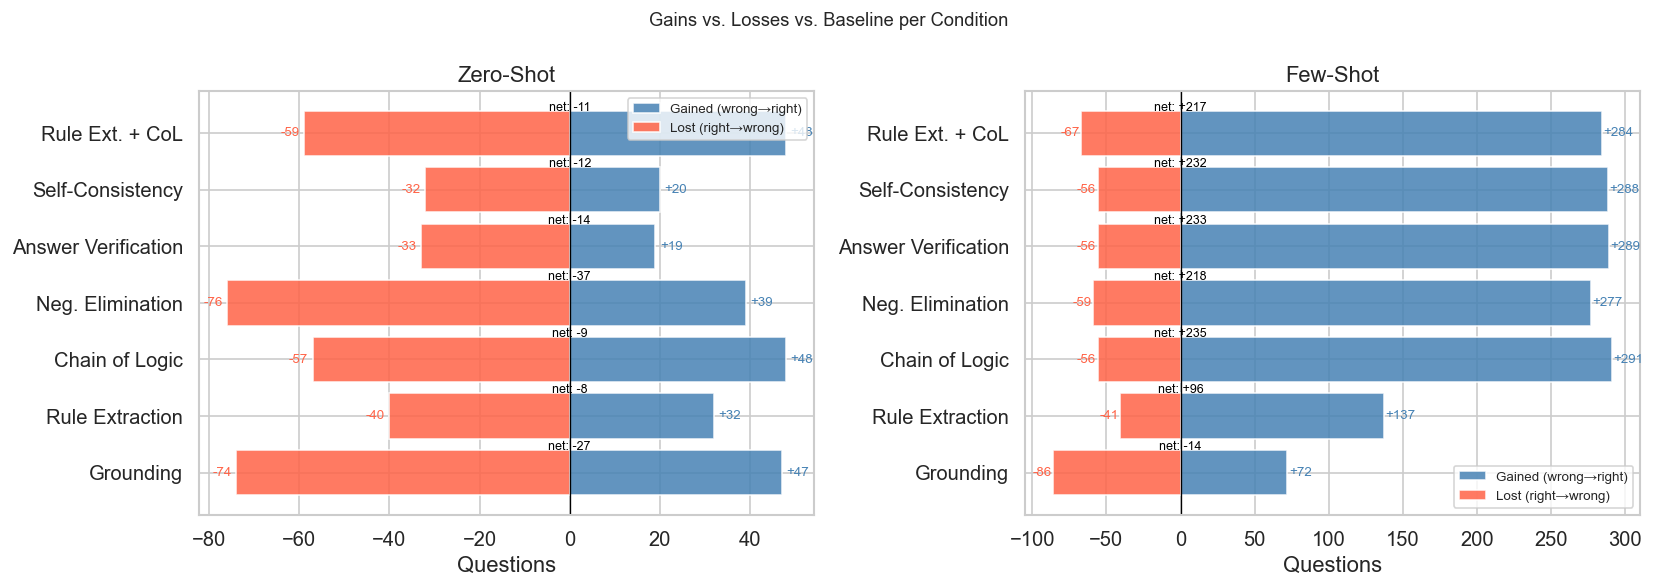

In [6]:
# Plot: Gains vs Losses as diverging bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rm, title in zip(axes, [rm_zs, rm_fs], ['Zero-Shot', 'Few-Shot']):
    y = range(len(rm))
    ax.barh(y, rm['Gained (↑)'], color='steelblue', alpha=0.85, label='Gained (wrong→right)')
    ax.barh(y, -rm['Lost (↓)'],  color='tomato',    alpha=0.85, label='Lost (right→wrong)')
    ax.axvline(0, color='black', linewidth=0.8)
    for yi, (_, row) in zip(y, rm.iterrows()):
        ax.text(row['Gained (↑)'] + 1, yi, f"+{row['Gained (↑)']}", va='center', fontsize=8, color='steelblue')
        ax.text(-row['Lost (↓)'] - 1, yi, f"-{row['Lost (↓)']}", va='center', ha='right', fontsize=8, color='tomato')
        ax.text(0, yi + 0.35, f"net: {row['Net']:+d}", va='bottom', ha='center', fontsize=7.5, color='black')
    ax.set_yticks(y)
    ax.set_yticklabels(rm['Name'])
    ax.set_xlabel('Questions')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Gains vs. Losses vs. Baseline per Condition', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'regression_matrix.png'), bbox_inches='tight')
plt.show()

### §4.2.2 Hard-Core Failures
Questions wrong across all 8 conditions (per regime). ZS HCF establishes the prompt-strategy ceiling; FS HCF is revisited in §4.5.3.


Zero-Shot — Hard-core failures (wrong in all conditions): 322
  Subject distribution:
{'CONTRACTS': 40, 'TORTS': 33, 'REAL PROP.': 32, 'EVIDENCE': 28, 'CRIM. LAW': 27, 'CONST. LAW': 9}
  Failure mode distribution:
{'FM2': 234, 'FM1': 88}

Few-Shot — Hard-core failures (wrong in all conditions): 111
  Subject distribution:
{'REAL PROP.': 16, 'CONTRACTS': 14, 'CRIM. LAW': 13, 'TORTS': 9, 'EVIDENCE': 8, 'CONST. LAW': 2}
  Failure mode distribution:
{'FM2': 74, 'FM1': 28}


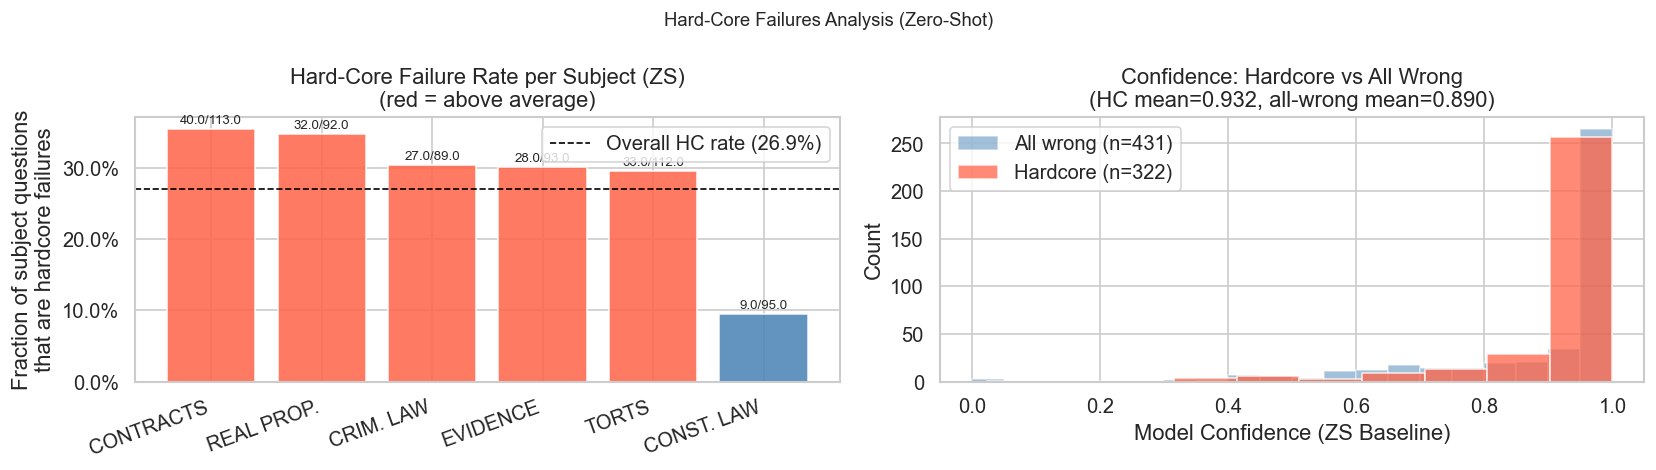

In [14]:
for df, label in [(zs_complete, 'Zero-Shot'), (fs_complete, 'Few-Shot')]:
    pivot = df.pivot_table(index='idx', columns='condition_id', values='is_correct', aggfunc='first')
    hardcore = pivot[pivot.apply(lambda row: not row.any(), axis=1)].index
    print(f'\n{label} — Hard-core failures (wrong in all conditions): {len(hardcore)}')
    if len(hardcore) == 0:
        continue

    meta = df[df['idx'].isin(hardcore) & (df['condition_id'] == 0)][['idx', 'subject', 'source']].drop_duplicates()
    print('  Subject distribution:')
    print(meta['subject'].value_counts().to_dict())

    if fm is not None:
        fm_hc = fm[fm['idx'].isin(hardcore)]
        print('  Failure mode distribution:')
        print(fm_hc['failure_mode'].value_counts().to_dict())

# --- HC rate per subject (zero-shot) ---
pivot_zs_hc = zs_complete.pivot_table(index='idx', columns='condition_id', values='is_correct', aggfunc='first')
hardcore_zs = set(pivot_zs_hc[pivot_zs_hc.apply(lambda row: not row.any(), axis=1)].index)

meta_all = zs_complete[zs_complete['condition_id'] == 0][['idx', 'subject', 'confidence']].copy()
meta_all['is_hardcore'] = meta_all['idx'].isin(hardcore_zs)

hc_rate = (meta_all[meta_all['subject'].isin(SUBJECTS)]
           .groupby('subject')
           .agg(n_total=('idx', 'count'), n_hc=('is_hardcore', 'sum'))
           .assign(hc_rate=lambda d: d['n_hc'] / d['n_total'])
           .sort_values('hc_rate', ascending=False))

overall_rate = len(hardcore_zs) / zs_complete['idx'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: HC rate per subject
ax = axes[0]
colors = ['tomato' if r > overall_rate else 'steelblue' for r in hc_rate['hc_rate']]
bars = ax.bar(range(len(hc_rate)), hc_rate['hc_rate'], color=colors, alpha=0.85)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
           label=f'Overall HC rate ({overall_rate:.1%})')
for xi, (subj, row) in enumerate(hc_rate.iterrows()):
    ax.text(xi, row['hc_rate'] + 0.008,
            f"{row['n_hc']}/{row['n_total']}", ha='center', fontsize=8)
ax.set_xticks(range(len(hc_rate)))
ax.set_xticklabels(hc_rate.index, rotation=20, ha='right')
ax.set_ylabel('Fraction of subject questions\nthat are hardcore failures')
ax.set_title('Hard-Core Failure Rate per Subject (ZS)\n(red = above average)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()

# Panel 2: Confidence distribution
ax = axes[1]
hc_conf      = meta_all[meta_all['is_hardcore']]['confidence'].dropna()
all_wrong_conf = zs_complete[(~zs_complete['is_correct']) & (zs_complete['condition_id'] == 0)]['confidence'].dropna()
ax.hist(all_wrong_conf, bins=20, alpha=0.5, label=f'All wrong (n={len(all_wrong_conf)})', color='steelblue')
ax.hist(hc_conf,        bins=10, alpha=0.75, label=f'Hardcore (n={len(hc_conf)})',         color='tomato')
ax.set_xlabel('Model Confidence (ZS Baseline)')
ax.set_ylabel('Count')
ax.set_title(f'Confidence: Hardcore vs All Wrong\n(HC mean={hc_conf.mean():.3f}, all-wrong mean={all_wrong_conf.mean():.3f})')
ax.legend()

plt.suptitle('Hard-Core Failures Analysis (Zero-Shot)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'hardcore_failures.png'), bbox_inches='tight')
plt.show()

## §4.3 H2 — Subject-Level Variation in Intervention Effectiveness

**H2:** Interventions differ in effectiveness across MBE subjects.  
Heatmap shows Δ accuracy vs. baseline per subject × condition.

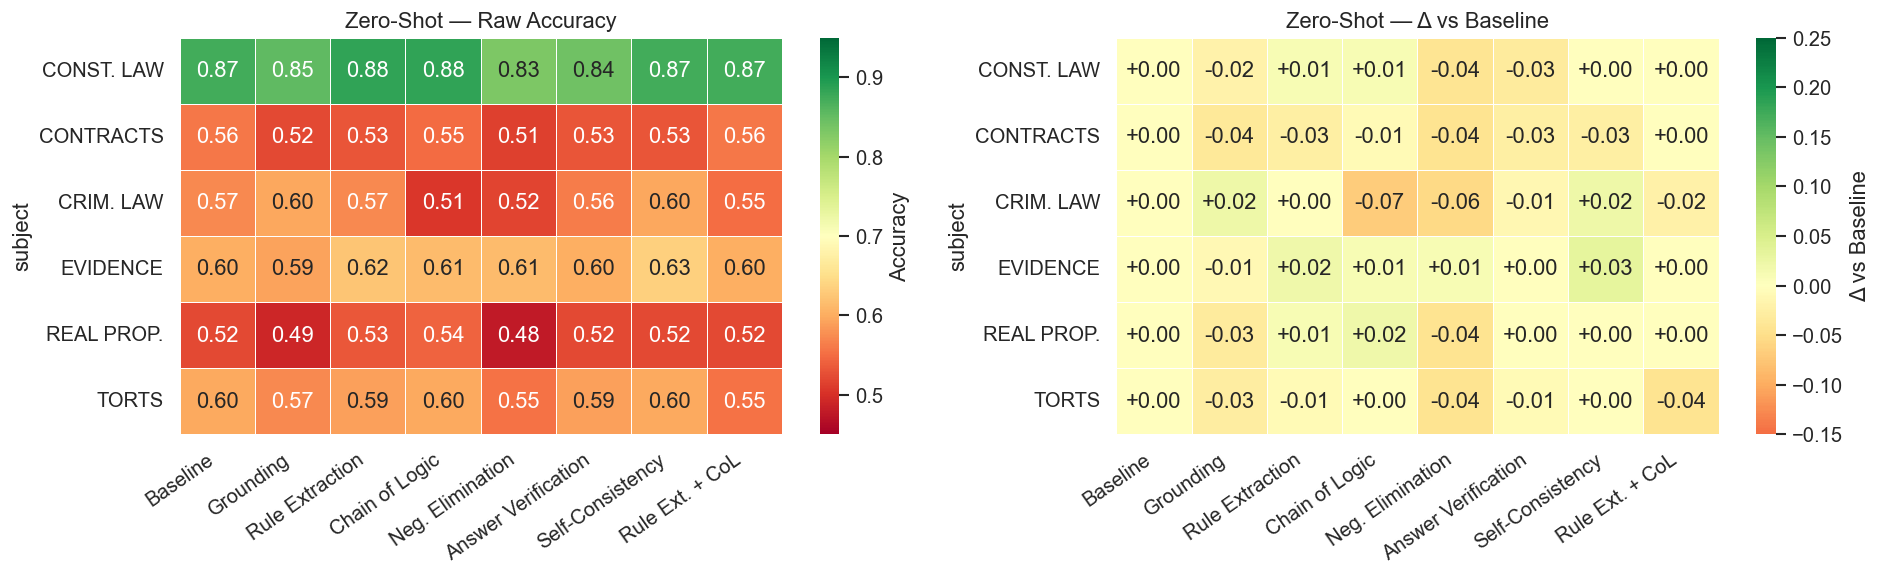

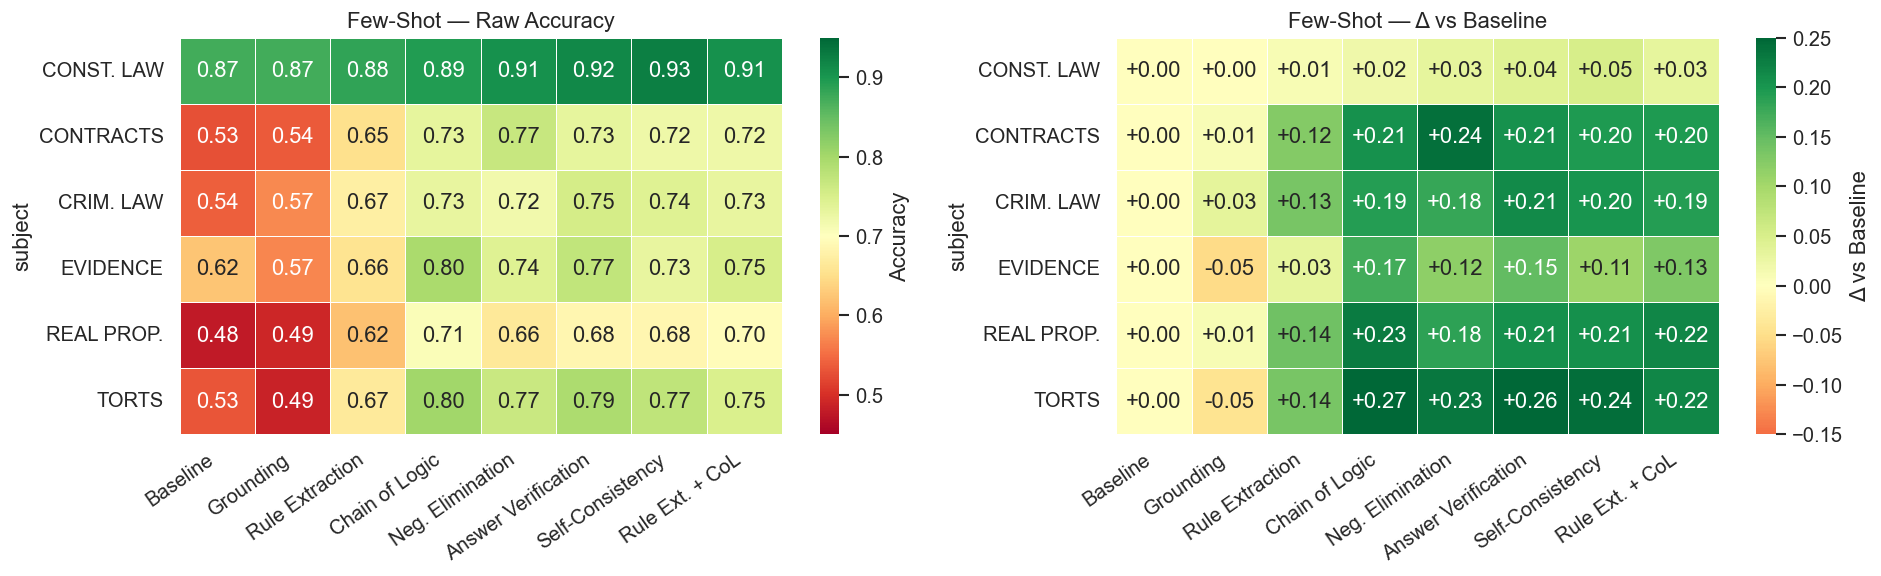

In [9]:
def subject_heatmap(df, title=''):
    df_subj = df[df['subject'].isin(SUBJECTS)].copy()
    pivot = df_subj.pivot_table(
        index='subject', columns='condition_id', values='is_correct', aggfunc='mean'
    )
    pivot.columns = [COND_NAMES[c] for c in pivot.columns]
    delta = pivot.sub(pivot['Baseline'], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0.45, vmax=0.95, linewidths=0.5, ax=axes[0],
                cbar_kws={'label': 'Accuracy'})
    axes[0].set_title(f'{title} — Raw Accuracy')
    axes[0].set_xlabel('')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')

    sns.heatmap(delta, annot=True, fmt='+.2f', cmap='RdYlGn',
                center=0, vmin=-0.15, vmax=0.25, linewidths=0.5, ax=axes[1],
                cbar_kws={'label': 'Δ vs Baseline'})
    axes[1].set_title(f'{title} — Δ vs Baseline')
    axes[1].set_xlabel('')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('-', '_')
    plt.savefig(os.path.join(FIG_DIR, f'subject_heatmap_{fname}.png'), bbox_inches='tight')
    plt.show()
    return pivot, delta

pivot_zs, delta_zs = subject_heatmap(zs_complete, 'Zero-Shot')
pivot_fs, delta_fs = subject_heatmap(fs_complete, 'Few-Shot')

## §4.4 H3 — Failure Mode Targeting by Condition

**H3:** Distinct interventions preferentially address FM1 (parametric override) vs. FM2 (reasoning failure).  
Fix rate = proportion of each failure mode's baseline errors corrected by the condition.


── Zero-Shot: Fix Rate per Condition (each cell = % of that FM's baseline errors now correct) ──


,FM1,FM2,Selectivity (FM1−FM2)
condition_name,,,
Answer Verification,2.4%,5.2%,-2.8%
Baseline,0.0%,0.0%,0.0%
Chain of Logic,13.8%,10.1%,3.8%
Grounding,15.4%,9.1%,6.4%
Neg. Elimination,12.2%,7.8%,4.4%
Rule Ext. + CoL,15.4%,9.4%,6.0%
Rule Extraction,8.9%,6.8%,2.1%
Self-Consistency,4.1%,4.9%,-0.8%



── Few-Shot: Fix Rate per Condition (each cell = % of that FM's baseline errors now correct) ──


,FM1,FM2,Selectivity (FM1−FM2)
condition_name,,,
Answer Verification,63.1%,59.0%,4.2%
Baseline,11.5%,11.7%,-0.3%
Chain of Logic,63.9%,56.0%,7.9%
Grounding,22.1%,11.7%,10.4%
Neg. Elimination,60.7%,56.0%,4.6%
Rule Ext. + CoL,63.1%,56.0%,7.1%
Rule Extraction,33.6%,32.6%,1.0%
Self-Consistency,62.3%,57.7%,4.6%


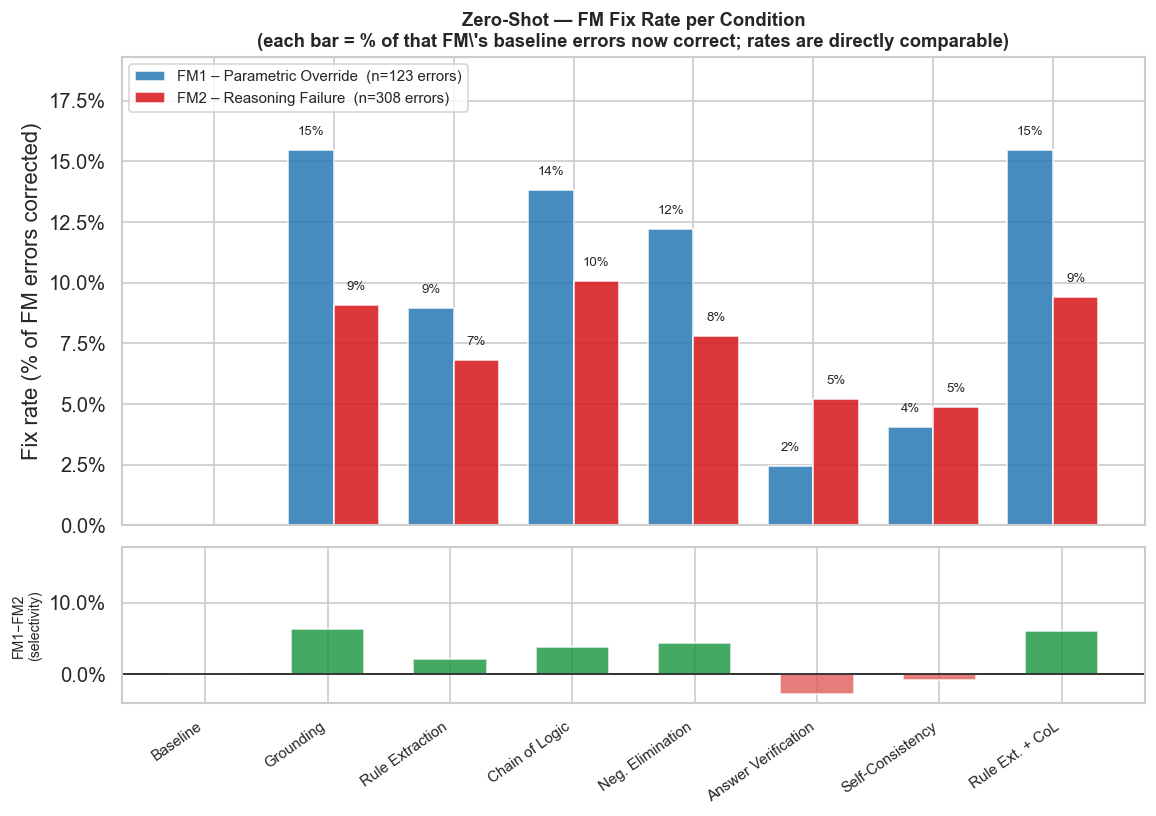

Saved → results/analysis/fm_by_condition_zeroshot.png


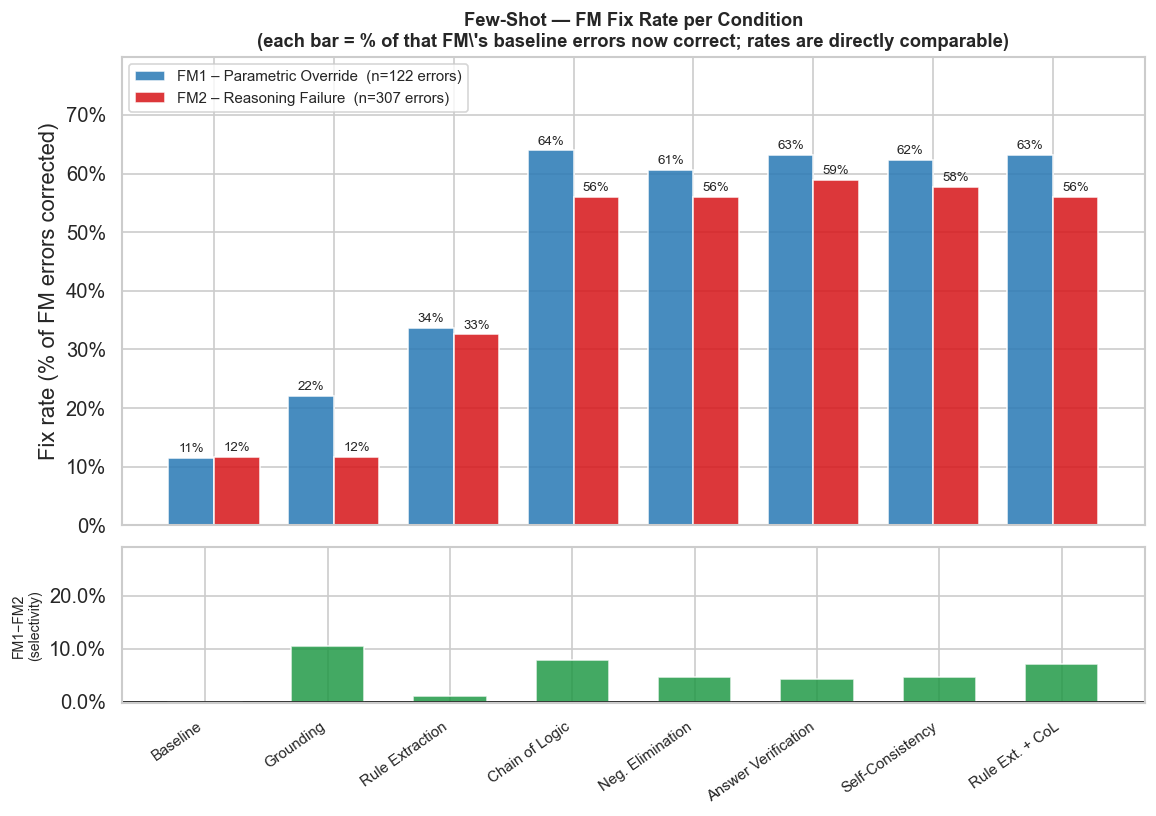

Saved → results/analysis/fm_by_condition_fewshot.png

── Overall Treatability: Average fix rate per FM type (excluding Baseline) ──
  Fix rates are % of each FM's own baseline errors → comparable despite FM1 n=123 vs FM2 n=308



,mode,failure_mode,n_errors,mean_fix,std_fix,min_fix,max_fix
0,Zero-Shot,FM1,123,10.3%,4.9%,2.4%,15.4%
1,Zero-Shot,FM2,308,7.6%,1.9%,4.9%,10.1%
2,Few-Shot,FM1,122,52.7%,16.0%,22.1%,63.9%
3,Few-Shot,FM2,307,47.0%,16.7%,11.7%,59.0%


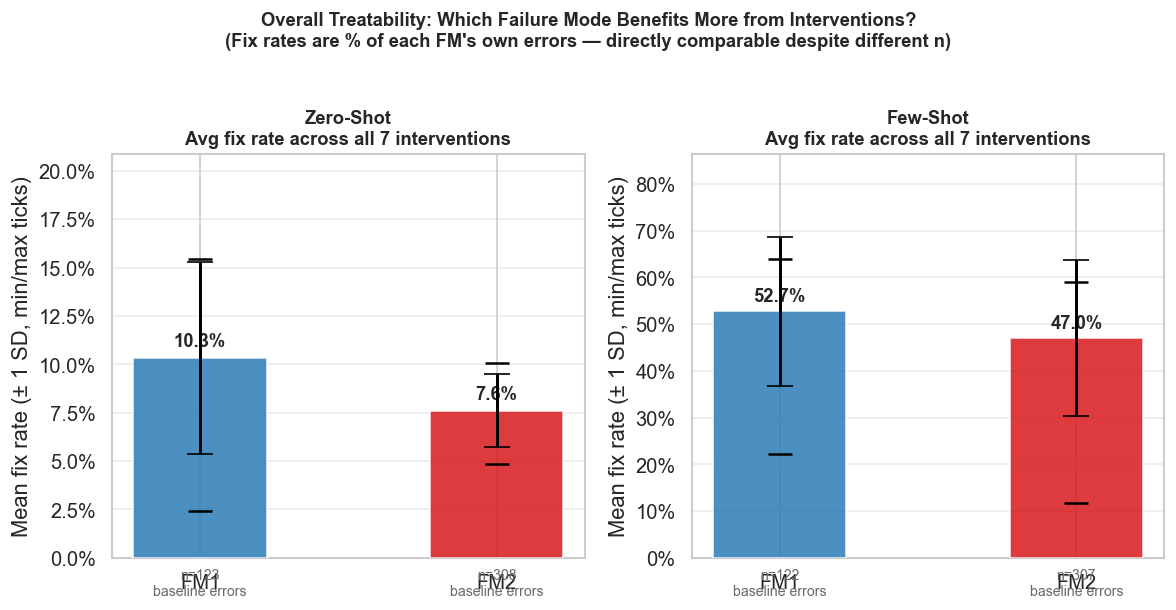

Saved → results/analysis/fm_treatability.png


In [10]:
if fm is None:
    print('No failure modes CSV found — skipping FM analysis.')
    print('To generate: python classify_failures.py')
else:
    # ── helper ──────────────────────────────────────────────────────────────
    def compute_fm_fix(df_mode):
        df_m = df_mode.merge(fm[['idx', 'failure_mode']], on='idx', how='left')
        be = df_m[df_m['condition_id'] == 0][['idx', 'failure_mode']]
        be = be[be['failure_mode'].isin(['FM1', 'FM2'])]
        n_fm = be['failure_mode'].value_counts().to_dict()  # {FM1: 123, FM2: 308}
        rows = []
        for cid in sorted(COND_NAMES):
            cd = df_m[df_m['condition_id'] == cid]
            for fmtype in ['FM1', 'FM2']:
                idx = be[be['failure_mode'] == fmtype]['idx']
                s = cd[cd['idx'].isin(idx)]
                if len(s) == 0:
                    continue
                rows.append({'condition_id': cid, 'condition_name': COND_NAMES[cid],
                             'failure_mode': fmtype, 'fix_rate': s['is_correct'].mean(),
                             'n_fm_total': n_fm.get(fmtype, 0)})
        return pd.DataFrame(rows), n_fm

    zs_fix, zs_n = compute_fm_fix(zs_complete)
    fs_fix, fs_n = compute_fm_fix(fs_complete)

    # ── tables ───────────────────────────────────────────────────────────────
    for label, fix_df in [('Zero-Shot', zs_fix), ('Few-Shot', fs_fix)]:
        piv = fix_df.pivot_table(index='condition_name', columns='failure_mode', values='fix_rate')
        piv['Selectivity (FM1−FM2)'] = piv['FM1'] - piv['FM2']
        piv.columns.name = None
        print(f'\n── {label}: Fix Rate per Condition (each cell = % of that FM\'s baseline errors now correct) ──')
        display(piv.style.format('{:.1%}').background_gradient(cmap='RdYlGn', subset=['FM1', 'FM2']))

    # ── Figure 1: Zero-Shot breakdown ────────────────────────────────────────
    fm1_col, fm2_col, sel_col = '#2c7bb6', '#d7191c', '#1a9641'

    def draw_fm_panel(fix_df, n_fm, mode_label, savename):
        piv = fix_df.pivot_table(index='condition_id', columns='failure_mode', values='fix_rate')
        cid_order = sorted(COND_NAMES)
        names    = [COND_NAMES[c] for c in cid_order]
        fm1_vals = [piv.loc[c, 'FM1'] if c in piv.index else 0 for c in cid_order]
        fm2_vals = [piv.loc[c, 'FM2'] if c in piv.index else 0 for c in cid_order]
        sel_vals = [f1 - f2 for f1, f2 in zip(fm1_vals, fm2_vals)]

        fig, (ax_bar, ax_sel) = plt.subplots(2, 1, figsize=(11, 7),
                                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.07})

        x = np.arange(len(cid_order))
        w = 0.38

        b1 = ax_bar.bar(x - w/2, fm1_vals, w,
                        label=f'FM1 – Parametric Override  (n={n_fm.get("FM1",0)} errors)',
                        color=fm1_col, alpha=0.87)
        b2 = ax_bar.bar(x + w/2, fm2_vals, w,
                        label=f'FM2 – Reasoning Failure  (n={n_fm.get("FM2",0)} errors)',
                        color=fm2_col, alpha=0.87)

        for bar in list(b1) + list(b2):
            h = bar.get_height()
            if h > 0.01:
                ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                            f'{h:.0%}', ha='center', va='bottom', fontsize=8)

        ax_bar.set_title(
            f'{mode_label} — FM Fix Rate per Condition\n'
            r'(each bar = % of that FM\'s baseline errors now correct; rates are directly comparable)',
            fontsize=11, fontweight='bold')
        ax_bar.set_ylabel('Fix rate (% of FM errors corrected)')
        ax_bar.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels([])
        ax_bar.legend(fontsize=9, loc='upper left')
        ax_bar.set_ylim(0, max(max(fm1_vals), max(fm2_vals)) * 1.25)

        sel_colors = [sel_col if v >= 0 else '#e06060' for v in sel_vals]
        ax_sel.bar(x, sel_vals, width=0.6, color=sel_colors, alpha=0.82)
        ax_sel.axhline(0, color='black', linewidth=0.9)
        ax_sel.set_ylabel('FM1−FM2\n(selectivity)', fontsize=8.5)
        ax_sel.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax_sel.set_xticks(x)
        ax_sel.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
        y_max = max(sel_vals) * 2.8 if max(sel_vals) > 0 else 0.15
        y_min = min(sel_vals) * 1.5 if min(sel_vals) < 0 else -0.02
        ax_sel.set_ylim(y_min, y_max)

        plt.tight_layout()
        path = os.path.join(FIG_DIR, savename)
        plt.savefig(path, bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Saved → {path}')

    draw_fm_panel(zs_fix, zs_n, 'Zero-Shot', 'fm_by_condition_zeroshot.png')
    draw_fm_panel(fs_fix, fs_n, 'Few-Shot',  'fm_by_condition_fewshot.png')

    # ── Figure 2: Overall treatability (average fix rate per FM × mode) ──────
    # Fix rates are % of each FM's own errors → directly comparable despite unequal n
    treat_rows = []
    for mode_label, fix_df in [('Zero-Shot', zs_fix), ('Few-Shot', fs_fix)]:
        non_base = fix_df[fix_df['condition_id'] != 0]
        for fmtype in ['FM1', 'FM2']:
            vals = non_base[non_base['failure_mode'] == fmtype]['fix_rate'].values
            treat_rows.append({
                'mode': mode_label, 'failure_mode': fmtype,
                'mean_fix': vals.mean(), 'std_fix': vals.std(),
                'min_fix': vals.min(), 'max_fix': vals.max(),
                'n_errors': (zs_n if mode_label == 'Zero-Shot' else fs_n).get(fmtype, 0)
            })
    treat_df = pd.DataFrame(treat_rows)

    print('\n── Overall Treatability: Average fix rate per FM type (excluding Baseline) ──')
    print('  Fix rates are % of each FM\'s own baseline errors → comparable despite FM1 n=123 vs FM2 n=308\n')
    display(treat_df[['mode','failure_mode','n_errors','mean_fix','std_fix','min_fix','max_fix']]
            .style.format({'mean_fix':'{:.1%}','std_fix':'{:.1%}',
                           'min_fix':'{:.1%}','max_fix':'{:.1%}'}))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
    for ax, mode_label in zip(axes, ['Zero-Shot', 'Few-Shot']):
        sub = treat_df[treat_df['mode'] == mode_label]
        colors = [fm1_col, fm2_col]
        bars = ax.bar(sub['failure_mode'], sub['mean_fix'], color=colors,
                      alpha=0.85, width=0.45, zorder=3)
        ax.errorbar(sub['failure_mode'], sub['mean_fix'],
                    yerr=sub['std_fix'], fmt='none', color='black',
                    capsize=8, linewidth=1.8, zorder=4)
        # range markers
        for _, row in sub.iterrows():
            ax.plot([row['failure_mode']], [row['min_fix']], '_', color='black',
                    markersize=14, markeredgewidth=1.5, zorder=5)
            ax.plot([row['failure_mode']], [row['max_fix']], '_', color='black',
                    markersize=14, markeredgewidth=1.5, zorder=5)
        # value labels
        for bar, (_, row) in zip(bars, sub.iterrows()):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + sub['std_fix'].max() * 0.08,
                    f'{h:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_title(f'{mode_label}\nAvg fix rate across all 7 interventions', fontsize=11, fontweight='bold')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_ylabel('Mean fix rate (± 1 SD, min/max ticks)')
        ax.set_ylim(0, max(sub['max_fix']) * 1.35)
        # annotate n
        for _, row in sub.iterrows():
            ax.text(row['failure_mode'], -0.025, f'n={row["n_errors"]}\nbaseline errors',
                    ha='center', va='top', fontsize=8.5, color='dimgray',
                    transform=ax.get_xaxis_transform())
        ax.grid(axis='y', alpha=0.4)
        ax.set_axisbelow(True)

    fig.suptitle(
        'Overall Treatability: Which Failure Mode Benefits More from Interventions?\n'
        '(Fix rates are % of each FM\'s own errors — directly comparable despite different n)',
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    path = os.path.join(FIG_DIR, 'fm_treatability.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → {path}')

## §4.5 H4 — Few-Shot Prompting as Moderator of Intervention Effectiveness

**H4:** Few-shot examples moderate intervention effectiveness.  
FS accuracy = Panel (b) of accuracy figure above (§4.1 / §4.2.1).  
This section adds: ZS vs. FS comparison and cross-mode hard-core failures.

### §4.5.2–4.5.3 Zero-Shot vs. Few-Shot Accuracy Comparison

Questions in both modes: 1193


,condition_id,zero_shot,few_shot,condition_name,few_shot_delta
0,0,0.640,0.604,Baseline,-0.037
1,1,0.618,0.592,Grounding,-0.026
2,2,0.634,0.684,Rule Extraction,+0.050
3,3,0.633,0.801,Chain of Logic,+0.168
4,4,0.609,0.786,Neg. Elimination,+0.177
5,5,0.629,0.799,Answer Verification,+0.170
6,6,0.630,0.798,Self-Consistency,+0.168
7,7,0.631,0.785,Rule Ext. + CoL,+0.154


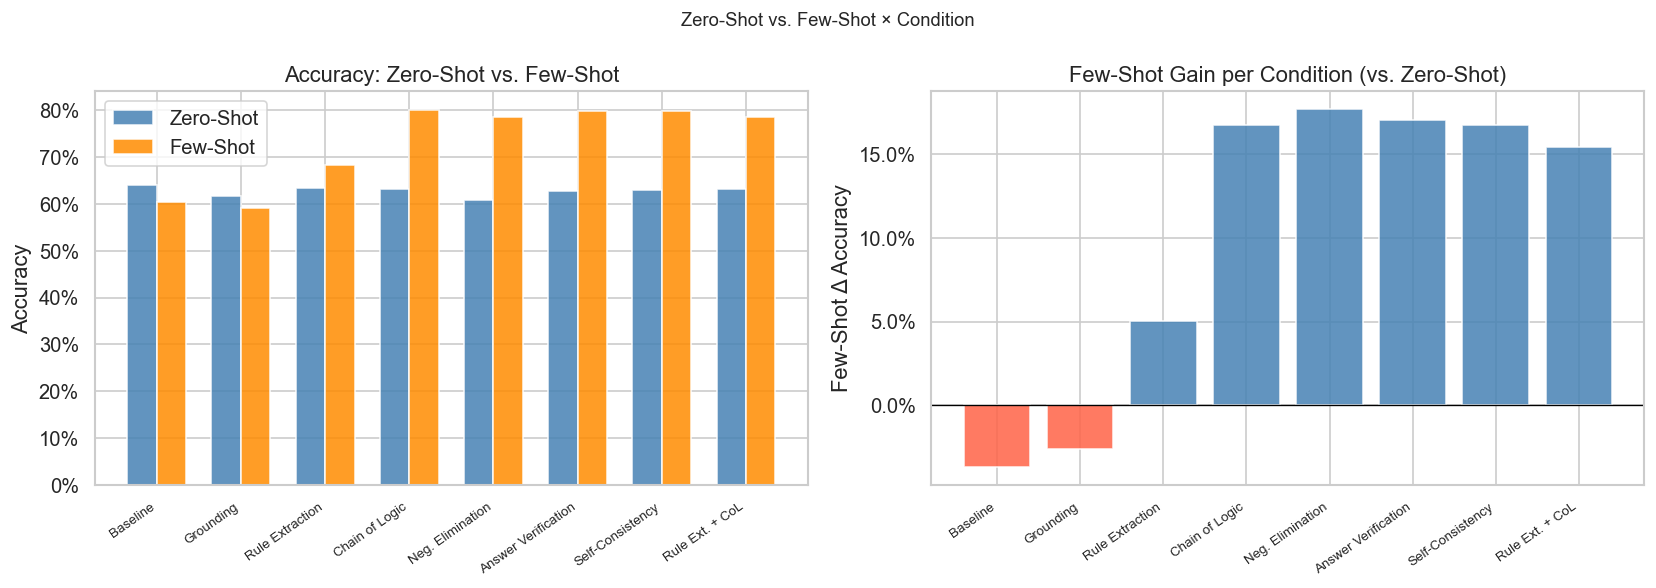

In [8]:
# Only use questions present in both modes
common_idx = set(zs_complete['idx'].unique()) & set(fs_complete['idx'].unique())
print(f'Questions in both modes: {len(common_idx)}')

zs_common = zs_complete[zs_complete['idx'].isin(common_idx)]
fs_common = fs_complete[fs_complete['idx'].isin(common_idx)]

acc_zs = zs_common.groupby('condition_id')['is_correct'].mean().rename('zero_shot')
acc_fs = fs_common.groupby('condition_id')['is_correct'].mean().rename('few_shot')
mode_df = pd.concat([acc_zs, acc_fs], axis=1).reset_index()
mode_df['condition_name'] = mode_df['condition_id'].map(COND_NAMES)
mode_df['few_shot_delta'] = mode_df['few_shot'] - mode_df['zero_shot']

display(mode_df.style.format({'zero_shot': '{:.3f}', 'few_shot': '{:.3f}', 'few_shot_delta': '{:+.3f}'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(mode_df))
w = 0.35
ax.bar(x - w/2, mode_df['zero_shot'], w, label='Zero-Shot', alpha=0.85, color='steelblue')
ax.bar(x + w/2, mode_df['few_shot'],  w, label='Few-Shot',  alpha=0.85, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(mode_df['condition_name'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Zero-Shot vs. Few-Shot')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()

ax = axes[1]
colors = ['steelblue' if d >= 0 else 'tomato' for d in mode_df['few_shot_delta']]
ax.bar(x, mode_df['few_shot_delta'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(mode_df['condition_name'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Few-Shot Δ Accuracy')
ax.set_title('Few-Shot Gain per Condition (vs. Zero-Shot)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Zero-Shot vs. Few-Shot × Condition', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'zs_vs_fs_by_condition.png'), bbox_inches='tight')
plt.show()

### §4.5.3 Cross-Mode Hard-Core Failures
Questions wrong across all 8 conditions in *both* regimes. FS HCF (111, 9.3%) vs. ZS HCF (322, 26.9%).

ZS  hardcore (wrong in all 8 ZS conditions):         322 / 1195  (26.9%)
FS  hardcore (wrong in all 8 FS conditions):         111 / 1193  (9.3%)
Both-mode hardcore (wrong in all 16 conditions):      93 / 1195  (7.8%)

Subject distribution (both-mode hardcore vs overall):


,Overall,Both-mode HC
subject,,
CONST. LAW,0.160,0.019
CONTRACTS,0.190,0.222
CRIM. LAW,0.150,0.204
EVIDENCE,0.157,0.148
REAL PROP.,0.155,0.278
TORTS,0.189,0.130



FM distribution (both-mode hardcore, n=93):
{'FM2': 66, 'FM1': 27}


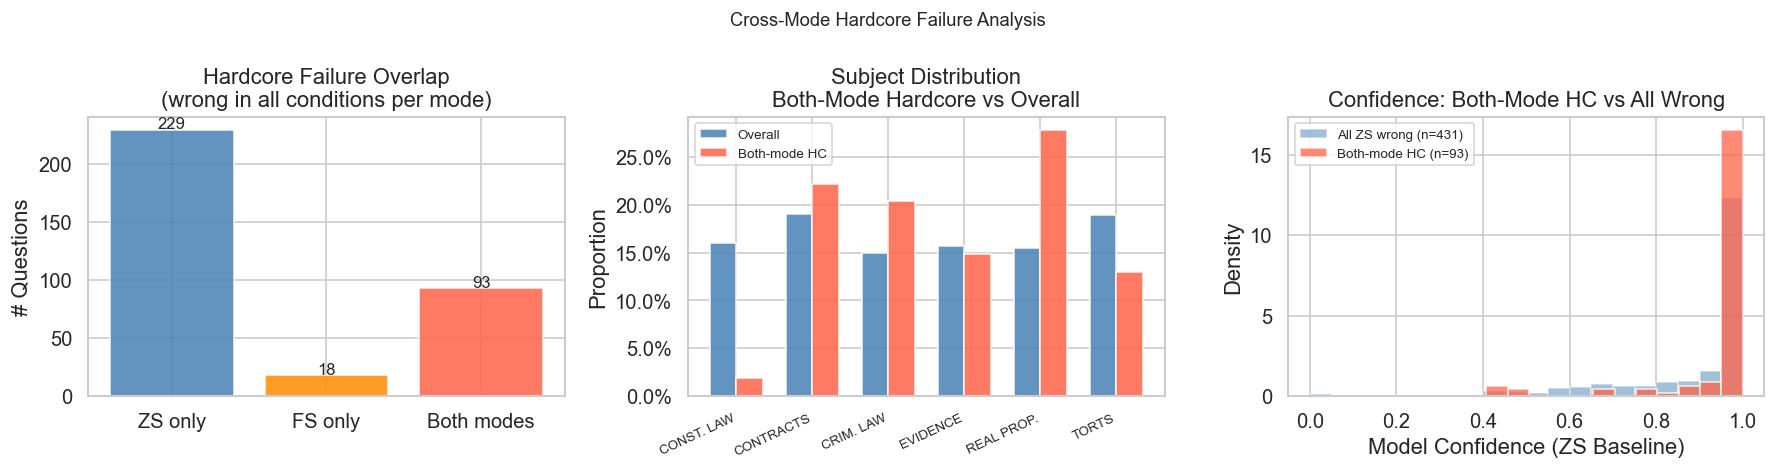

In [20]:
def get_hardcore(df):
    pivot = df.pivot_table(index='idx', columns='condition_id',
                           values='is_correct', aggfunc='first')
    return set(pivot[pivot.apply(lambda r: not r.any(), axis=1)].index)

hc_zs = get_hardcore(zs_complete)
hc_fs = get_hardcore(fs_complete)
hc_both = hc_zs & hc_fs

n_zs = zs_complete['idx'].nunique()
n_fs = fs_complete['idx'].nunique()

print(f'ZS  hardcore (wrong in all 8 ZS conditions):        {len(hc_zs):4d} / {n_zs}  ({len(hc_zs)/n_zs:.1%})')
print(f'FS  hardcore (wrong in all 8 FS conditions):        {len(hc_fs):4d} / {n_fs}  ({len(hc_fs)/n_fs:.1%})')
print(f'Both-mode hardcore (wrong in all 16 conditions):    {len(hc_both):4d} / {n_zs}  ({len(hc_both)/n_zs:.1%})')
print()

# Characterise the both-mode hardcore questions
both_meta = zs_complete[
    zs_complete['idx'].isin(hc_both) & (zs_complete['condition_id'] == 0)
][['idx', 'subject', 'source', 'confidence']].copy()

print('Subject distribution (both-mode hardcore vs overall):')
overall_s = zs_complete[zs_complete['condition_id'] == 0]['subject'].value_counts(normalize=True)
hc_s      = both_meta['subject'].value_counts(normalize=True)
comp = pd.DataFrame({'Overall': overall_s, 'Both-mode HC': hc_s}).fillna(0).round(3)
display(comp)

if fm is not None:
    fm_hc = fm[fm['idx'].isin(hc_both)]
    print(f'\nFM distribution (both-mode hardcore, n={len(fm_hc)}):')
    print(fm_hc['failure_mode'].value_counts().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Venn-style bar: ZS only, FS only, both
ax = axes[0]
zs_only  = len(hc_zs - hc_fs)
fs_only  = len(hc_fs - hc_zs)
both_n   = len(hc_both)
ax.bar(['ZS only', 'FS only', 'Both modes'],
       [zs_only, fs_only, both_n],
       color=['steelblue', 'darkorange', 'tomato'], alpha=0.85)
for xi, val in enumerate([zs_only, fs_only, both_n]):
    ax.text(xi, val + 1, str(val), ha='center', fontsize=10)
ax.set_ylabel('# Questions')
ax.set_title('Hardcore Failure Overlap\n(wrong in all conditions per mode)')

# Subject proportion comparison
ax = axes[1]
x = np.arange(len(comp))
w = 0.35
ax.bar(x - w/2, comp['Overall'],     w, label='Overall',       color='steelblue', alpha=0.85)
ax.bar(x + w/2, comp['Both-mode HC'], w, label='Both-mode HC', color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Proportion')
ax.set_title('Subject Distribution\nBoth-Mode Hardcore vs Overall')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=8)

# Confidence of both-mode HC vs all wrong
ax = axes[2]
all_wrong_conf = zs_complete[
    (~zs_complete['is_correct']) & (zs_complete['condition_id'] == 0)
]['confidence'].dropna()
hc_conf = both_meta['confidence'].dropna()
ax.hist(all_wrong_conf, bins=20, alpha=0.5, label=f'All ZS wrong (n={len(all_wrong_conf)})',
        color='steelblue', density=True)
ax.hist(hc_conf, bins=12, alpha=0.75, label=f'Both-mode HC (n={len(hc_conf)})',
        color='tomato', density=True)
ax.set_xlabel('Model Confidence (ZS Baseline)')
ax.set_ylabel('Density')
ax.set_title('Confidence: Both-Mode HC vs All Wrong')
ax.legend(fontsize=8)

plt.suptitle('Cross-Mode Hardcore Failure Analysis', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cross_mode_hardcore.png'), bbox_inches='tight')
plt.show()

## §4.6 Secondary Findings

### §4.6.1 Expected Calibration Error
Bootstrap 95% CIs on ΔECE vs. baseline. Conditions 5 and 7 FS excluded (logprob artefact).

── ECE significance vs baseline (95% bootstrap CI) ──


,mode,name,ece,delta,ci_lo,ci_hi,sig
0,Zero-Shot,Baseline,0.2976,+0.0000,+0.0000,+0.0000,baseline
1,Zero-Shot,Grounding,0.3021,+0.0045,-0.0154,+0.0249,ns
2,Zero-Shot,Rule Extraction,0.2971,-0.0005,-0.0179,+0.0124,ns
3,Zero-Shot,Chain of Logic,0.2993,+0.0017,-0.0158,+0.0196,ns
4,Zero-Shot,Neg. Elimination,0.3003,+0.0027,-0.0176,+0.0174,ns
5,Zero-Shot,Answer Verification,0.3648,+0.0672,+0.0488,+0.0800,sig. worse
6,Zero-Shot,Self-Consistency,0.3272,+0.0296,+0.0129,+0.0432,sig. worse
7,Zero-Shot,Rule Ext. + CoL,0.2987,+0.0011,-0.0188,+0.0168,ns
8,Few-Shot,Baseline,0.3228,+0.0000,+0.0000,+0.0000,baseline
9,Few-Shot,Grounding,0.3228,-0.0001,-0.0211,+0.0201,ns


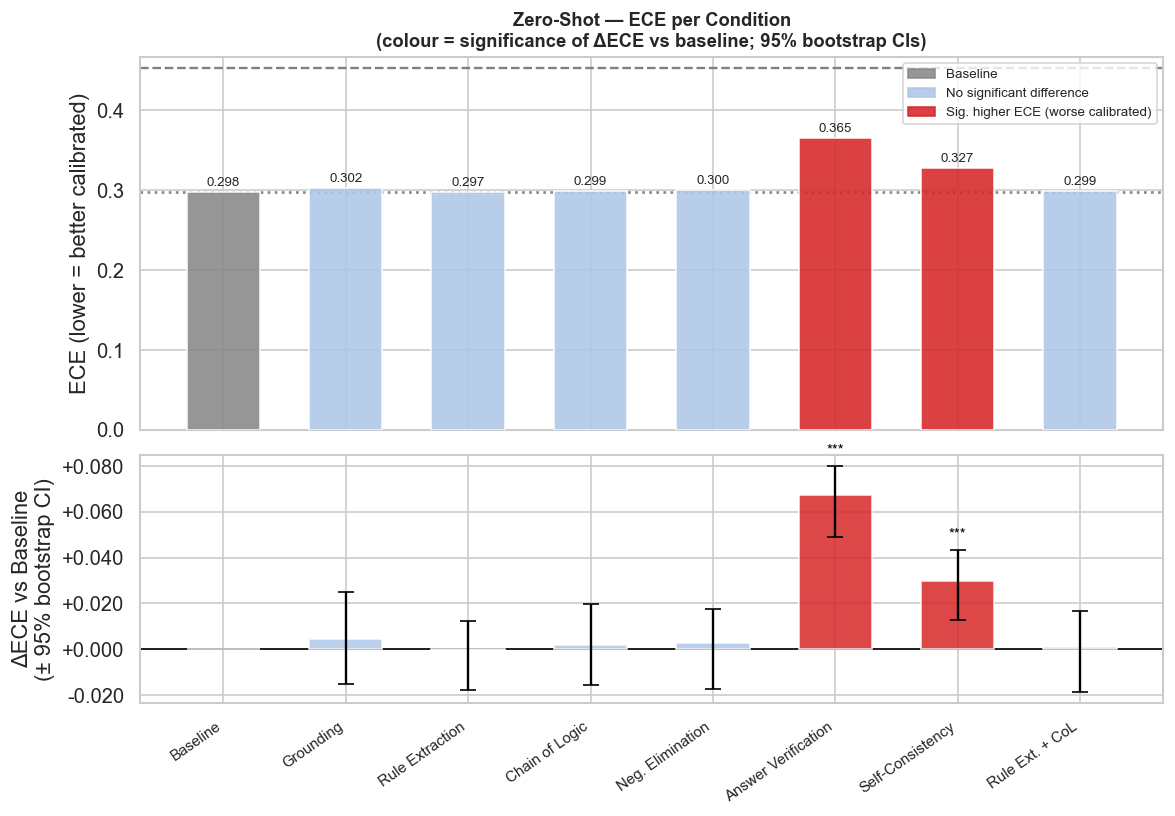

Saved → results/analysis/ece_per_condition_zeroshot.png


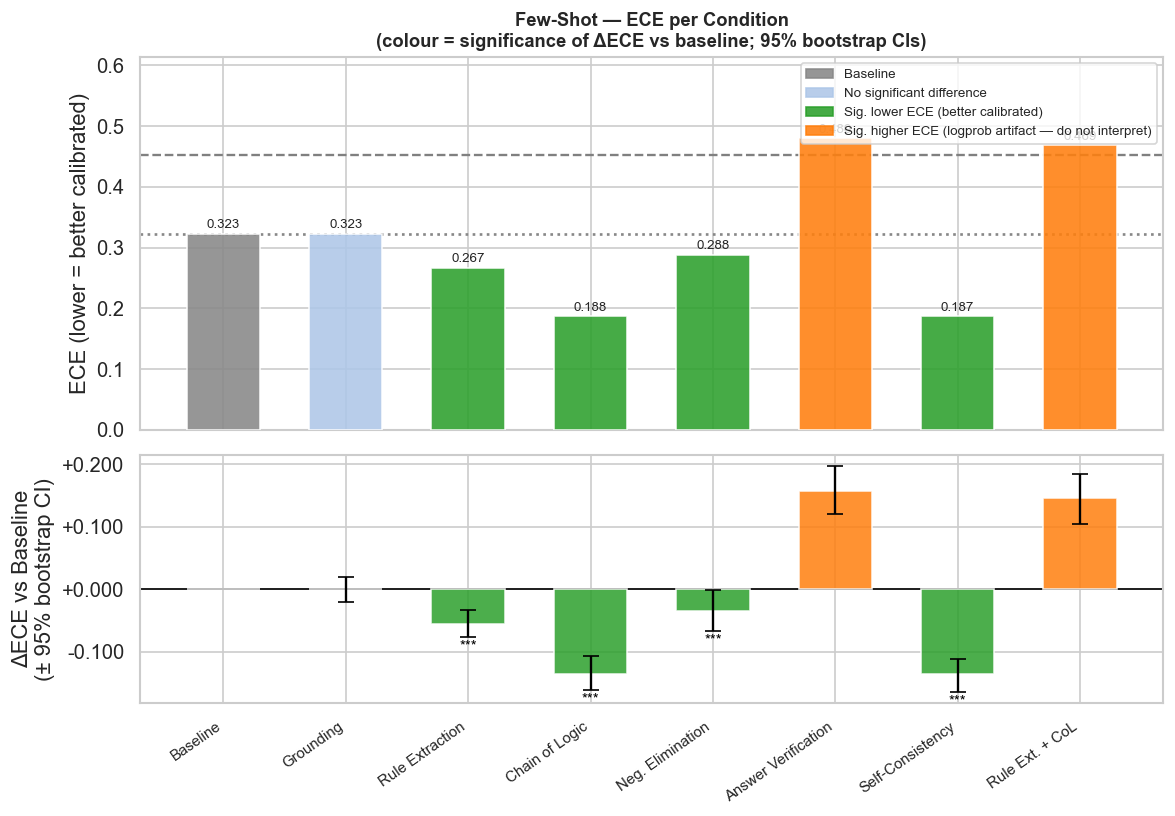

Saved → results/analysis/ece_per_condition_fewshot.png


In [16]:
# ── ECE significance analysis: bootstrap 95% CIs on ΔECE vs baseline ────────
# Fast numpy ECE (matches evaluator.py binning logic)
def ece_np(conf, corr, n_bins=10):
    conf = np.clip(conf, 0, 1)
    edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.searchsorted(edges[1:], conf)
    n = len(conf)
    ece = 0.0
    for b in range(n_bins):
        m = bin_idx == b
        if m.sum() == 0: continue
        ece += (m.sum()/n) * abs(conf[m].mean() - corr[m].mean())
    return ece

def bootstrap_ece_delta(conf_c, corr_c, conf_b, corr_b, n_boot=1000, seed=42):
    """Paired bootstrap CI on ECE_condition − ECE_baseline."""
    rng = np.random.default_rng(seed)
    n = len(conf_c)
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        ix = rng.integers(0, n, n)
        deltas[i] = ece_np(conf_c[ix], corr_c[ix]) - ece_np(conf_b[ix], corr_b[ix])
    return np.percentile(deltas, [2.5, 97.5])

# Conditions whose logprobs come from a verification call (not the answer token) → ECE is an artifact
ANOMALY_FS = {5, 7}

def load_conf(df_all, cid):
    d = df_all[df_all['condition_id'] == cid]
    return d['confidence'].values, d['is_correct'].astype(float).values

ece_rows = []
for mode_label, df_mode in [('Zero-Shot', zs_complete), ('Few-Shot', fs_complete)]:
    conf_b, corr_b = load_conf(df_mode, 0)
    ece_b = ece_np(conf_b, corr_b)
    for cid in sorted(COND_NAMES):
        conf_c, corr_c = load_conf(df_mode, cid)
        ece_c = ece_np(conf_c, corr_c)
        anomaly = (mode_label == 'Few-Shot' and cid in ANOMALY_FS)
        if cid == 0:
            lo, hi, sig = 0.0, 0.0, 'baseline'
        else:
            lo, hi = bootstrap_ece_delta(conf_c, corr_c, conf_b, corr_b)
            if   hi < 0:  sig = 'sig. better'
            elif lo > 0:  sig = 'artifact' if anomaly else 'sig. worse'
            else:         sig = 'ns'
        ece_rows.append({'mode': mode_label, 'cid': cid, 'name': COND_NAMES[cid],
                         'ece': ece_c, 'ece_base': ece_b, 'delta': ece_c - ece_b,
                         'ci_lo': lo, 'ci_hi': hi, 'sig': sig, 'anomaly': anomaly})

ece_df = pd.DataFrame(ece_rows)

# Summary table
print('── ECE significance vs baseline (95% bootstrap CI) ──')
disp = ece_df.pivot_table(index='name', columns='mode', values=['ece','delta','sig'], aggfunc='first')
display(ece_df[['mode','name','ece','delta','ci_lo','ci_hi','sig']]
        .style.format({'ece':'{:.4f}','delta':'{:+.4f}','ci_lo':'{:+.4f}','ci_hi':'{:+.4f}'})
        .map(lambda v: 'background-color: #c6efce' if v == 'sig. better' else
                            ('background-color: #ffc7ce' if v in ('sig. worse','artifact') else ''),
                  subset=['sig']))

# ── Plot: separate Zero-Shot and Few-Shot ──────────────────────────────────────
SIG_COLORS = {'baseline':'#888888','sig. better':'#2ca02c','ns':'#aec7e8',
              'sig. worse':'#d62728','artifact':'#ff7f0e'}
SIG_LABELS = {'baseline':'Baseline','sig. better':'Sig. lower ECE (better calibrated)',
              'ns':'No significant difference',
              'sig. worse':'Sig. higher ECE (worse calibrated)',
              'artifact':'Sig. higher ECE (logprob artifact — do not interpret)'}

for mode_label in ['Zero-Shot', 'Few-Shot']:
    sub = ece_df[ece_df['mode'] == mode_label].sort_values('cid')
    names   = sub['name'].tolist()
    eces    = sub['ece'].values
    deltas  = sub['delta'].values
    ci_los  = sub['ci_lo'].values
    ci_his  = sub['ci_hi'].values
    sigs    = sub['sig'].tolist()
    base_ece = sub[sub['cid'] == 0]['ece'].values[0]

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 7),
                                          gridspec_kw={'height_ratios':[3,2],'hspace':0.08})
    x = np.arange(len(names))
    bar_colors = [SIG_COLORS[s] for s in sigs]

    # ── top: absolute ECE ──
    bars = ax_top.bar(x, eces, color=bar_colors, alpha=0.88, width=0.6, zorder=3)
    ax_top.axhline(0.453, color='gray', linestyle='--', linewidth=1.4, zorder=2,
                   label='Dahl et al. 2024 pooled ECE (0.453)')
    ax_top.axhline(base_ece, color='#888888', linestyle=':', linewidth=1.6, zorder=2,
                   label=f'Baseline ECE ({base_ece:.3f})')
    for bar, e in zip(bars, eces):
        ax_top.text(bar.get_x()+bar.get_width()/2, e+0.004,
                    f'{e:.3f}', ha='center', va='bottom', fontsize=8)
    ax_top.set_xticks(x); ax_top.set_xticklabels([])
    ax_top.set_ylabel('ECE (lower = better calibrated)')
    ax_top.set_title(f'{mode_label} — ECE per Condition\n(colour = significance of ΔECE vs baseline; 95% bootstrap CIs)',
                     fontsize=11, fontweight='bold')
    ax_top.set_ylim(0, max(eces)*1.28)
    # colour legend
    from matplotlib.patches import Patch
    seen = list(dict.fromkeys(sigs))
    handles = [Patch(color=SIG_COLORS[s], alpha=0.88, label=SIG_LABELS[s]) for s in seen]
    ax_top.legend(handles=handles, fontsize=8, loc='upper right')

    # ── bottom: delta ECE + CIs ──
    err_lo = np.maximum(deltas - ci_los, 0)
    err_hi = np.maximum(ci_his - deltas, 0)
    err_lo[0] = 0; err_hi[0] = 0
    ax_bot.bar(x, deltas, color=bar_colors, alpha=0.85, width=0.6, zorder=3)
    ax_bot.errorbar(x[1:], deltas[1:], yerr=[err_lo[1:], err_hi[1:]],
                    fmt='none', color='black', capsize=5, linewidth=1.4, zorder=4)
    ax_bot.axhline(0, color='black', linewidth=1.0)
    ax_bot.set_ylabel('ΔECE vs Baseline\n(± 95% bootstrap CI)')
    ax_bot.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:+.3f}'))
    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
    # star markers
    for xi, (s, d, hi_) in enumerate(zip(sigs, deltas, ci_his)):
        if s in ('sig. better','sig. worse') and xi > 0:
            ypos = (hi_+0.004) if d > 0 else (ci_los[xi]-0.004)
            ax_bot.text(xi, ypos, '***', ha='center', fontsize=9,
                        va='bottom' if d > 0 else 'top', color='black')

    plt.tight_layout()
    fname = f'ece_per_condition_{"zeroshot" if mode_label=="Zero-Shot" else "fewshot"}.png'
    plt.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved → {FIG_DIR}/{fname}')

### §4.6.2 Self-Consistency Agreement Rate (Condition 6)


Zero-Shot — Condition 6 agreement:


,unanimous,n,accuracy
0,2/1 split,153,0.418301
1,3/3 unanimous,1042,0.660269


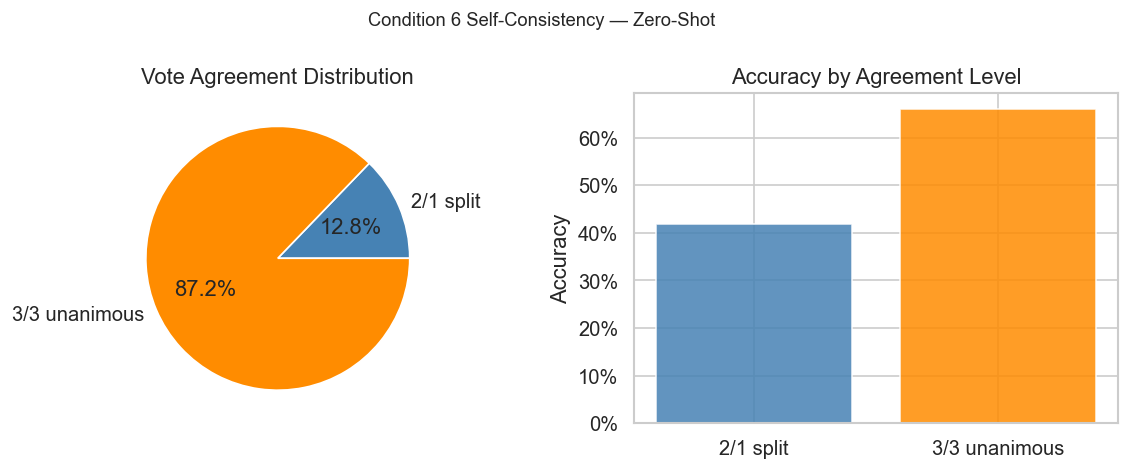


Few-Shot — Condition 6 agreement:


,unanimous,n,accuracy
0,2/1 split,57,0.403509
1,3/3 unanimous,1136,0.817782


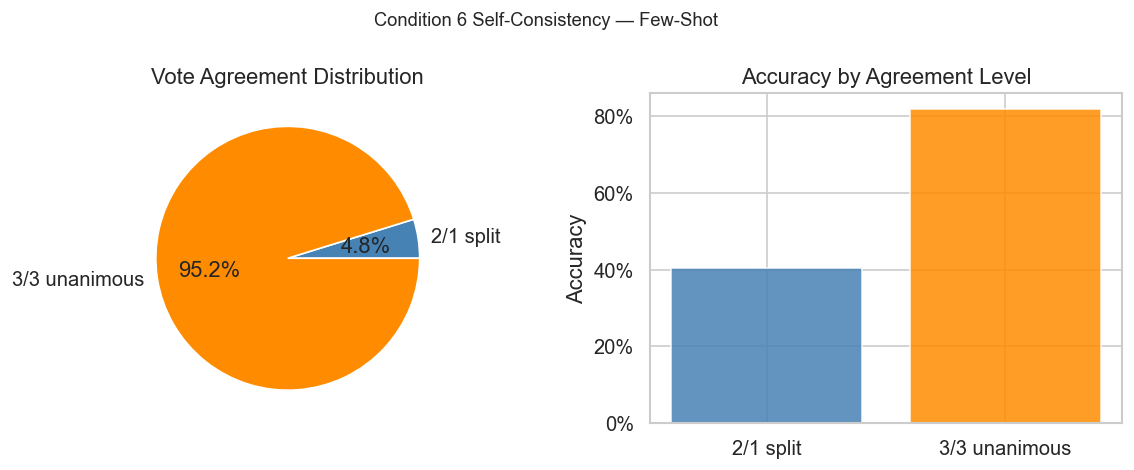

In [11]:
for df, label in [(zs_complete, 'Zero-Shot'), (fs_complete, 'Few-Shot')]:
    cond6 = df[df['condition_id'] == 6].copy()
    if cond6.empty:
        print(f'{label}: no Condition 6 data')
        continue

    cond6['votes'] = (cond6['confidence'] * 3).round().astype(int)
    cond6['unanimous'] = cond6['votes'] == 3

    summary = cond6.groupby('unanimous').agg(
        n=('is_correct', 'count'),
        accuracy=('is_correct', 'mean')
    ).reset_index()
    summary['unanimous'] = summary['unanimous'].map({True: '3/3 unanimous', False: '2/1 split'})

    print(f'\n{label} — Condition 6 agreement:')
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].pie(summary['n'], labels=summary['unanimous'], autopct='%1.1f%%',
                colors=['steelblue', 'darkorange'])
    axes[0].set_title('Vote Agreement Distribution')
    axes[1].bar(summary['unanimous'], summary['accuracy'],
                color=['steelblue', 'darkorange'], alpha=0.85)
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy by Agreement Level')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    plt.suptitle(f'Condition 6 Self-Consistency — {label}', fontsize=11)
    plt.tight_layout()
    safe = label.lower().replace('-', '_').replace(' ', '_')
    plt.savefig(os.path.join(FIG_DIR, f'cond6_agreement_{safe}.png'), bbox_inches='tight')
    plt.show()

### §4.6.3 Cost-Accuracy Trade-Offs

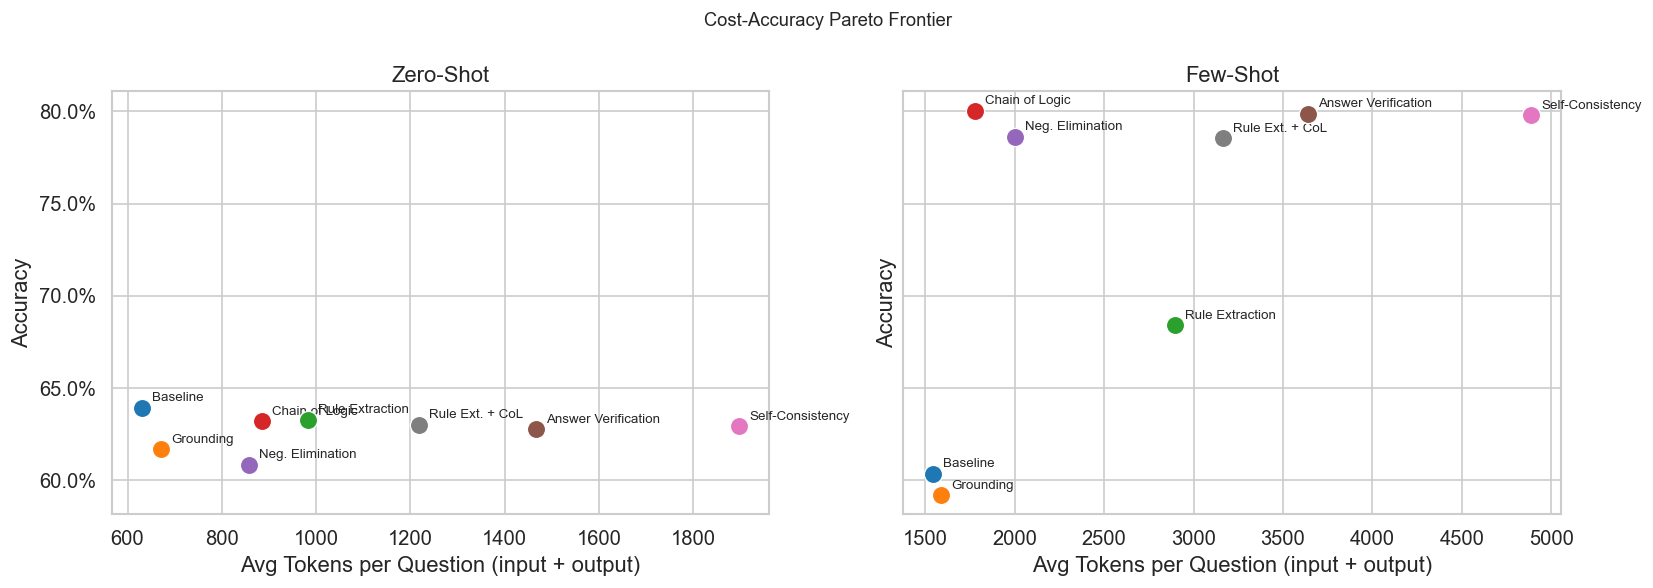

In [7]:
def cost_accuracy(df, label=''):
    df['total_tokens'] = df['tokens_input'].fillna(0) + df['tokens_output'].fillna(0)
    summary = df.groupby(['condition_id', 'condition_name']).agg(
        accuracy=('is_correct', 'mean'),
        avg_tokens=('total_tokens', 'mean'),
    ).reset_index()
    return summary

ca_zs = cost_accuracy(zs_complete)
ca_fs = cost_accuracy(fs_complete)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, ca, title in zip(axes, [ca_zs, ca_fs], ['Zero-Shot', 'Few-Shot']):
    for _, row in ca.iterrows():
        cid = int(row['condition_id'])
        ax.scatter(row['avg_tokens'], row['accuracy'], s=120, color=COLORS[cid],
                   zorder=5, edgecolors='white', linewidths=0.8)
        ax.annotate(row['condition_name'], (row['avg_tokens'], row['accuracy']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel('Avg Tokens per Question (input + output)')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Cost-Accuracy Pareto Frontier', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cost_accuracy_pareto.png'), bbox_inches='tight')
plt.show()

## Summary Metrics
All key accuracy, calibration, cost and confidence metrics.

In [15]:
for path, label in [('results/zero_shot/summary.csv', 'Zero-Shot'),
                     ('results/few_shot/summary.csv', 'Few-Shot')]:
    if not os.path.exists(path):
        continue
    s = pd.read_csv(path)
    print(f'\n=== {label} Summary ===')
    display(s[['condition_id', 'condition_name', 'accuracy', 'ece',
                'mean_confidence', 'overconfidence_gap', 'estimated_cost_usd']]
            .style.format({'accuracy': '{:.3f}', 'ece': '{:.4f}',
                           'mean_confidence': '{:.3f}', 'overconfidence_gap': '{:+.3f}',
                           'estimated_cost_usd': '${:.4f}'}))


=== Zero-Shot Summary ===


,condition_id,condition_name,accuracy,ece,mean_confidence,overconfidence_gap,estimated_cost_usd
0,0,Baseline,0.639,0.2976,0.921,+0.281,$0.1695
1,1,Grounding,0.617,0.3021,0.893,+0.276,$0.1740
2,2,Rule Extraction,0.633,0.2971,0.916,+0.284,$0.2564
3,3,Chain of Logic,0.632,0.2993,0.928,+0.296,$0.3118
4,4,Negative Elimination,0.608,0.3003,0.907,+0.299,$0.2986
5,5,Answer Verification,0.628,0.3648,0.989,+0.361,$0.3943
6,6,Self-Consistency (N=3),0.629,0.3272,0.955,+0.326,$0.5144
7,7,Rule Extraction + CoL,0.630,0.2987,0.929,+0.299,$0.3877



=== Few-Shot Summary ===


,condition_id,condition_name,accuracy,ece,mean_confidence,overconfidence_gap,estimated_cost_usd
0,0,Baseline,0.604,0.3228,0.926,+0.323,$0.3329
1,1,Grounding,0.592,0.3228,0.911,+0.319,$0.3386
2,2,Rule Extraction,0.684,0.2667,0.951,+0.267,$0.6293
3,3,Chain of Logic,0.801,0.1876,0.973,+0.173,$0.4534
4,4,Negative Elimination,0.786,0.2885,0.786,-0.000,$0.6103
5,5,Answer Verification,0.799,0.4797,0.372,-0.426,$0.8934
6,6,Self-Consistency (N=3),0.798,0.1869,0.984,+0.186,$1.1128
7,7,Rule Extraction + CoL,0.785,0.4687,0.372,-0.413,$0.7512


### Supplementary: Overconfidence by Condition
Mean confidence on correct vs. wrong answers per condition.

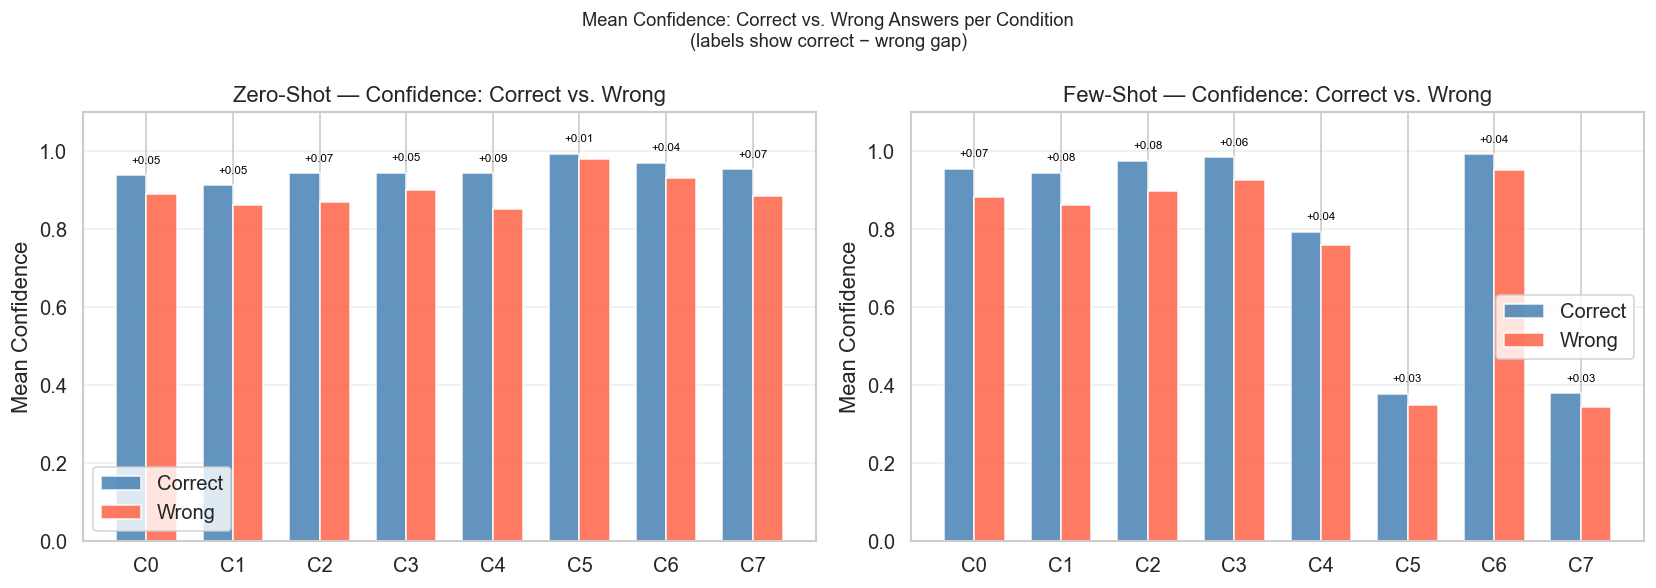

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, mode_label in zip(axes,
                               [zs_complete, fs_complete],
                               ['Zero-Shot', 'Few-Shot']):
    cids = list(range(8))
    conf_correct = [df[(df['condition_id'] == c) &  df['is_correct']]['confidence'].mean() for c in cids]
    conf_wrong   = [df[(df['condition_id'] == c) & ~df['is_correct']]['confidence'].mean() for c in cids]

    x = np.arange(8)
    w = 0.35
    ax.bar(x - w/2, conf_correct, w, color='steelblue', alpha=0.85, label='Correct')
    ax.bar(x + w/2, conf_wrong,   w, color='tomato',    alpha=0.85, label='Wrong')
    ax.set_xticks(x)
    ax.set_xticklabels([f'C{i}' for i in cids])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Mean Confidence')
    ax.set_title(f'{mode_label} — Confidence: Correct vs. Wrong')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for i, (cc, cw) in enumerate(zip(conf_correct, conf_wrong)):
        if not (np.isnan(cc) or np.isnan(cw)):
            ax.text(i, max(cc, cw) + 0.03, f'{cc-cw:+.2f}',
                    ha='center', fontsize=7, color='black')

plt.suptitle('Mean Confidence: Correct vs. Wrong Answers per Condition\n'
             '(labels show correct − wrong gap)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'overconfidence_by_condition.png'), bbox_inches='tight')
plt.show()

## Generate Thesis Figures
Run `thesis_figures.py` to produce all APA7 production figures in `results/thesis_figures/`.

In [ ]:
# ── Generate all production thesis figures ──────────────────────────────────
exec(open('thesis_figures.py').read())
